In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import seaborn as sns


In [27]:
# Load data
df_jpm = pd.read_csv('data/time_series_jpm_renamed.csv', index_col=0, parse_dates=True)
df_hfr = pd.read_csv('data/HFR_2000.csv', index_col=0, parse_dates=True)

# Load S&P 500 data
sp500 = pd.read_csv('data/hf_returns/sp500.csv', index_col=0, parse_dates=True)

# Global filter: 2020-01-01 to 2025-12-31
global_start = '2020-01-01'
global_end = '2025-12-31'

jpm_period = df_jpm.loc[global_start:global_end].dropna(axis=1, how='any')
hfr_period = df_hfr.loc[global_start:global_end].dropna(axis=1, how='any')
sp500_period = sp500.loc[global_start:global_end]['SP500TR']

print(f"JPM funds with complete data from {global_start} to {global_end}: {jpm_period.shape[1]}")


JPM funds with complete data from 2020-01-01 to 2025-12-31: 348


## 2. Train/Test Split & Selection

In [28]:
# Define Train and Test periods
train_start = '2020-01-01'
train_end = '2022-12-31'

test_start = '2023-01-01'
test_end = '2025-12-31'

jpm_train = jpm_period.loc[train_start:train_end]
hfr_train = hfr_period.loc[train_start:train_end]

# Function to calculate annualized Sharpe Ratio
def get_annualized_sharpe(returns):
    return returns.mean() / returns.std() * np.sqrt(12)

# Calculate Sharpe Ratios on the training set
jpm_train_sharpe = get_annualized_sharpe(jpm_train)
hfr_train_sharpe = get_annualized_sharpe(hfr_train)

# Select Top 20% funds based on Sharpe Ratio
def get_top_20_percent_funds(sharpe_series):
    threshold = sharpe_series.quantile(0.80)
    return sharpe_series[sharpe_series >= threshold].index.tolist()

jpm_top20_funds = get_top_20_percent_funds(jpm_train_sharpe)
hfr_top20_funds = get_top_20_percent_funds(hfr_train_sharpe)

print(f"JPM top 20% selected funds: {len(jpm_top20_funds)}")
print(f"HFR top 20% selected funds: {len(hfr_top20_funds)}")

# Slice the global period data for only the test period, and only the selected funds
jpm_test = jpm_period.loc[test_start:test_end, jpm_top20_funds]
hfr_test = hfr_period.loc[test_start:test_end, hfr_top20_funds]
sp500_test = sp500_period.loc[test_start:test_end]

print(f"JPM Test Set Shape: {jpm_test.shape}")


JPM top 20% selected funds: 70
HFR top 20% selected funds: 71
JPM Test Set Shape: (36, 70)


In [29]:
def calculate_metrics(returns, sp500_returns, mean_fund_vol=None):
    """
    Calculate comprehensive portfolio metrics from a series of monthly returns.
    """
    # 1. Mean Return (Annualized) %
    mean_return_ann = returns.mean() * 12 * 100
    
    # 2. CAGR %
    cum_return = (1 + returns).prod()
    n_years = len(returns) / 12
    cagr = (cum_return ** (1 / n_years) - 1 if n_years > 0 else np.nan) * 100
    
    # 3. Volatility (Annualized) %
    volatility = returns.std() * np.sqrt(12) * 100
    
    if mean_fund_vol is not None:
        vol_div_ratio = mean_fund_vol / volatility if volatility != 0 else np.nan
    else:
        vol_div_ratio = np.nan

    
    # 4. Sharpe Ratio (Annualized)
    sharpe_ratio_ann = (returns.mean() / returns.std() * np.sqrt(12)) if returns.std() != 0 else np.nan
    
    # 5. Max Drawdown %
    cum_index = (1 + returns).cumprod()
    running_max = cum_index.cummax()
    drawdown = (cum_index - running_max) / running_max
    max_drawdown = drawdown.min() * 100
    
    # 6. Calmar Ratio
    calmar_ratio = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan
    
    # 7. Correlation with S&P 500
    correlation = returns.corr(sp500_returns)
    
    # 8. Proportion of Positive Months %
    pos_months = (returns > 0).mean() * 100
    
    # 9. Upside / Downside Capture (%)
    up_idx = sp500_returns > 0
    down_idx = sp500_returns < 0
    
    port_up_ret = (1 + returns[up_idx]).prod() - 1
    sp500_up_ret = (1 + sp500_returns[up_idx]).prod() - 1
    up_capture = (port_up_ret / sp500_up_ret * 100) if sp500_up_ret != 0 else np.nan
    
    port_down_ret = (1 + returns[down_idx]).prod() - 1
    sp500_down_ret = (1 + sp500_returns[down_idx]).prod() - 1
    down_capture = (port_down_ret / sp500_down_ret * 100) if sp500_down_ret != 0 else np.nan
    
    # 10. Correlation when S&P500 is below its 1st quartile
    q1_sp500 = sp500_returns.quantile(0.25)
    below_q1_idx = sp500_returns < q1_sp500
    corr_below_q1 = returns[below_q1_idx].corr(sp500_returns[below_q1_idx])
    
    # 11. Regression Metrics (Alpha, Beta, R2, t-stats)
    y = returns.values
    x = sp500_returns.values
    n = len(x)
    
    cov_matrix = np.cov(x, y)
    beta = cov_matrix[0, 1] / cov_matrix[0, 0] if cov_matrix[0, 0] != 0 else np.nan
    alpha = np.mean(y) - beta * np.mean(x)
    
    y_pred = alpha + beta * x
    residuals = y - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    
    r2 = (1 - (ss_res / ss_tot)) * 100 if ss_tot != 0 else np.nan
    
    s_err = np.sqrt(ss_res / (n - 2)) if n > 2 else np.nan
    ss_xx = np.sum((x - np.mean(x))**2)
    
    beta_se = s_err / np.sqrt(ss_xx) if ss_xx != 0 else np.nan
    alpha_se = s_err * np.sqrt(1/n + (np.mean(x)**2) / ss_xx) if ss_xx != 0 else np.nan
    
    beta_tstat = beta / beta_se if beta_se != 0 and not np.isnan(beta_se) else np.nan
    alpha_tstat = alpha / alpha_se if alpha_se != 0 and not np.isnan(alpha_se) else np.nan
    
    # Annualized Alpha (converted to %)
    alpha_ann = ((1 + alpha)**12 - 1) * 100
    
    return {
        'Mean Return (Ann) %': mean_return_ann,
        'CAGR %': cagr,
        'Volatility (Ann) %': volatility,
        'Vol Div Ratio': vol_div_ratio,
        'Sharpe Ratio (Ann)': sharpe_ratio_ann,
        'Max Drawdown %': max_drawdown,
        'Calmar Ratio': calmar_ratio,
        'Correlation with SP500': correlation,
        'Positive Months %': pos_months,
        'Upside Capture %': up_capture,
        'Downside Capture %': down_capture,
        'Correlation (SP500 < Q1)': corr_below_q1,
        'Beta': beta,
        'Beta t-stat': beta_tstat,
        'Alpha (Ann) %': alpha_ann,
        'Alpha t-stat': alpha_tstat,
        'R-squared %': r2
    }


In [30]:
def bootstrap_worker(data_df, sp500_series, n, weight_scheme):
    """Worker function to process a single bootstrap iteration."""
    cols = data_df.columns.tolist()
    sel = np.random.choice(cols, size=n, replace=False)
    returns_subset = data_df[sel]
    
    if weight_scheme == 'ew':
        weights = np.ones(n) / n
    elif weight_scheme == 'iv':
        vols = returns_subset.std()
        # Handle zero vol to avoid divide-by-zero
        vols = vols.replace(0, np.nan)
        inv_vols = 1.0 / vols
        weights = inv_vols / inv_vols.sum()
        weights = weights.fillna(1.0 / n).values
        
    mean_fund_vol = returns_subset.std().mean() * np.sqrt(12) * 100
    port_ret = (returns_subset * weights).sum(axis=1)
    return calculate_metrics(port_ret, sp500_series, mean_fund_vol)

def run_bootstrap_n(data_df, sp500_series, n, n_boot=1000, weight_scheme='ew'):
    """
    Runs the bootstrap simulation utilizing a ThreadPoolExecutor for concurrent multi-worker processing.
    """
    res = []
    if len(data_df.columns) < n:
        return pd.DataFrame()
        
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(bootstrap_worker, data_df, sp500_series, n, weight_scheme) for _ in range(n_boot)]
        
        for future in tqdm(as_completed(futures), total=n_boot, desc=f"Bootstrap n={n} ({weight_scheme.upper()})", leave=False, disable=True):
            res.append(future.result())
            
    return pd.DataFrame(res)

metrics_to_plot = [
    'Mean Return (Ann) %', 
    'CAGR %', 
    'Volatility (Ann) %',
    'Vol Div Ratio', 
    'Sharpe Ratio (Ann)', 
    'Max Drawdown %', 
    'Calmar Ratio', 
    'Correlation with SP500',
    'Positive Months %',
    'Upside Capture %',
    'Downside Capture %',
    'Correlation (SP500 < Q1)',
    'Beta',
    'Beta t-stat',
    'Alpha (Ann) %',
    'Alpha t-stat',
    'R-squared %'
]


In [31]:
# Setup Plotting Helpers to avoid code duplication

def plot_distributions(res_jpm_10, res_hfr_10, title_prefix=""):
    n_metrics = len(metrics_to_plot)
    nrows = int(np.ceil(n_metrics / 3))
    fig, axes = plt.subplots(nrows, 3, figsize=(18, 5 * nrows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        
        # JPM Data
        if not res_jpm_10.empty:
            d_jpm = res_jpm_10[metric].dropna()
            ax.hist(d_jpm, bins=30, color='skyblue', edgecolor='black', alpha=0.5, label='JPM Data')
            med_jpm = d_jpm.median()
            ax.axvline(med_jpm, color='blue', linestyle='dashed', linewidth=2, label=f'JPM Med: {med_jpm:.2f}')
            
        # HFR Data
        if not res_hfr_10.empty:
            d_hfr = res_hfr_10[metric].dropna()
            ax.hist(d_hfr, bins=30, color='orange', edgecolor='black', alpha=0.5, label='HFR Data')
            med_hfr = d_hfr.median()
            ax.axvline(med_hfr, color='red', linestyle='dashed', linewidth=2, label=f'HFR Med: {med_hfr:.2f}')
        
        ax.set_title(f'{title_prefix} Distribution of {metric}')
        ax.set_xlabel(metric)
        ax.set_ylabel('Frequency')
        ax.legend()

    # Hide any unused subplots
    for i in range(n_metrics, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()


def run_scaling_analysis(jpm_period, hfr_period, sp500_period, weight_scheme='ew'):
    n_values = range(3, 16)
    q_results_jpm = {m: {'median': [], 'q1': [], 'q3': []} for m in metrics_to_plot}
    q_results_hfr = {m: {'median': [], 'q1': [], 'q3': []} for m in metrics_to_plot}

    for n in tqdm(n_values, desc=f"Scaling sizes ({weight_scheme.upper()})"):
        df_n_jpm = run_bootstrap_n(jpm_period, sp500_period, n, n_boot=1000, weight_scheme=weight_scheme)
        df_n_hfr = run_bootstrap_n(hfr_period, sp500_period, n, n_boot=1000, weight_scheme=weight_scheme)
        
        for m in metrics_to_plot:
            if not df_n_jpm.empty:
                q_results_jpm[m]['median'].append(df_n_jpm[m].median())
                q_results_jpm[m]['q1'].append(df_n_jpm[m].quantile(0.25))
                q_results_jpm[m]['q3'].append(df_n_jpm[m].quantile(0.75))
            else:
                q_results_jpm[m]['median'].append(np.nan)
                q_results_jpm[m]['q1'].append(np.nan)
                q_results_jpm[m]['q3'].append(np.nan)

            if not df_n_hfr.empty:
                q_results_hfr[m]['median'].append(df_n_hfr[m].median())
                q_results_hfr[m]['q1'].append(df_n_hfr[m].quantile(0.25))
                q_results_hfr[m]['q3'].append(df_n_hfr[m].quantile(0.75))
            else:
                q_results_hfr[m]['median'].append(np.nan)
                q_results_hfr[m]['q1'].append(np.nan)
                q_results_hfr[m]['q3'].append(np.nan)

    res_jpm = {m: pd.DataFrame(q_results_jpm[m], index=n_values) for m in metrics_to_plot}
    res_hfr = {m: pd.DataFrame(q_results_hfr[m], index=n_values) for m in metrics_to_plot}

    return res_jpm, res_hfr


def plot_scaling(res_jpm, res_hfr, title_prefix=""):
    n_values = res_jpm[metrics_to_plot[0]].index
    nrows_scale = int(np.ceil(len(metrics_to_plot) / 3))
    fig, axes = plt.subplots(nrows_scale, 3, figsize=(18, 5 * nrows_scale))
    axes = axes.flatten()

    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        
        df_jpm = res_jpm[metric]
        df_hfr = res_hfr[metric]
        
        ax.plot(df_jpm.index, df_jpm['median'], marker='o', linestyle='-', color='blue', linewidth=2, label='JPM Median')
        ax.fill_between(df_jpm.index, df_jpm['q1'], df_jpm['q3'], color='blue', alpha=0.1, label='JPM Q1-Q3')

        ax.plot(df_hfr.index, df_hfr['median'], marker='s', linestyle='-', color='red', linewidth=2, label='HFR Median')
        ax.fill_between(df_hfr.index, df_hfr['q1'], df_hfr['q3'], color='red', alpha=0.1, label='HFR Q1-Q3')
        
        ax.set_title(f'{title_prefix} {metric} vs. Size')
        ax.set_xlabel('Number of Funds (n)')
        ax.set_ylabel(f'{metric}')
        ax.set_xticks(list(n_values))
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend()

    for i in range(len(metrics_to_plot), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()


def plot_proportion_grid_search(res_df, title_prefix=""):
    if res_df.empty:
        return
        
    vol_thresholds = np.arange(5.0, 10.5, 0.5)
    sr_thresholds = np.arange(1.4, 2.6, 0.1)
    
    grid = pd.DataFrame(index=vol_thresholds, columns=sr_thresholds)
    
    for v in vol_thresholds:
        for sr in sr_thresholds:
            cond = (res_df['Volatility (Ann) %'] > v) & (res_df['Sharpe Ratio (Ann)'] > sr)
            grid.loc[v, sr] = cond.mean() * 100
            
    grid = grid.astype(float)
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(grid, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Proportion (%)'})
    plt.title(f"{title_prefix} Proportion (Vol > y, SR > x)")
    plt.xlabel("Sharpe Ratio Threshold")
    plt.ylabel("Volatility Threshold (%)")
    plt.gca().invert_yaxis()
    plt.show()

def run_grid_searches(res_1, res_2, label_1="JPM", label_2="HFR", title_prefix=""):
    if not res_1.empty:
        plot_proportion_grid_search(res_1, title_prefix=f"{title_prefix} {label_1}")
    if not res_2.empty:
        plot_proportion_grid_search(res_2, title_prefix=f"{title_prefix} {label_2}")


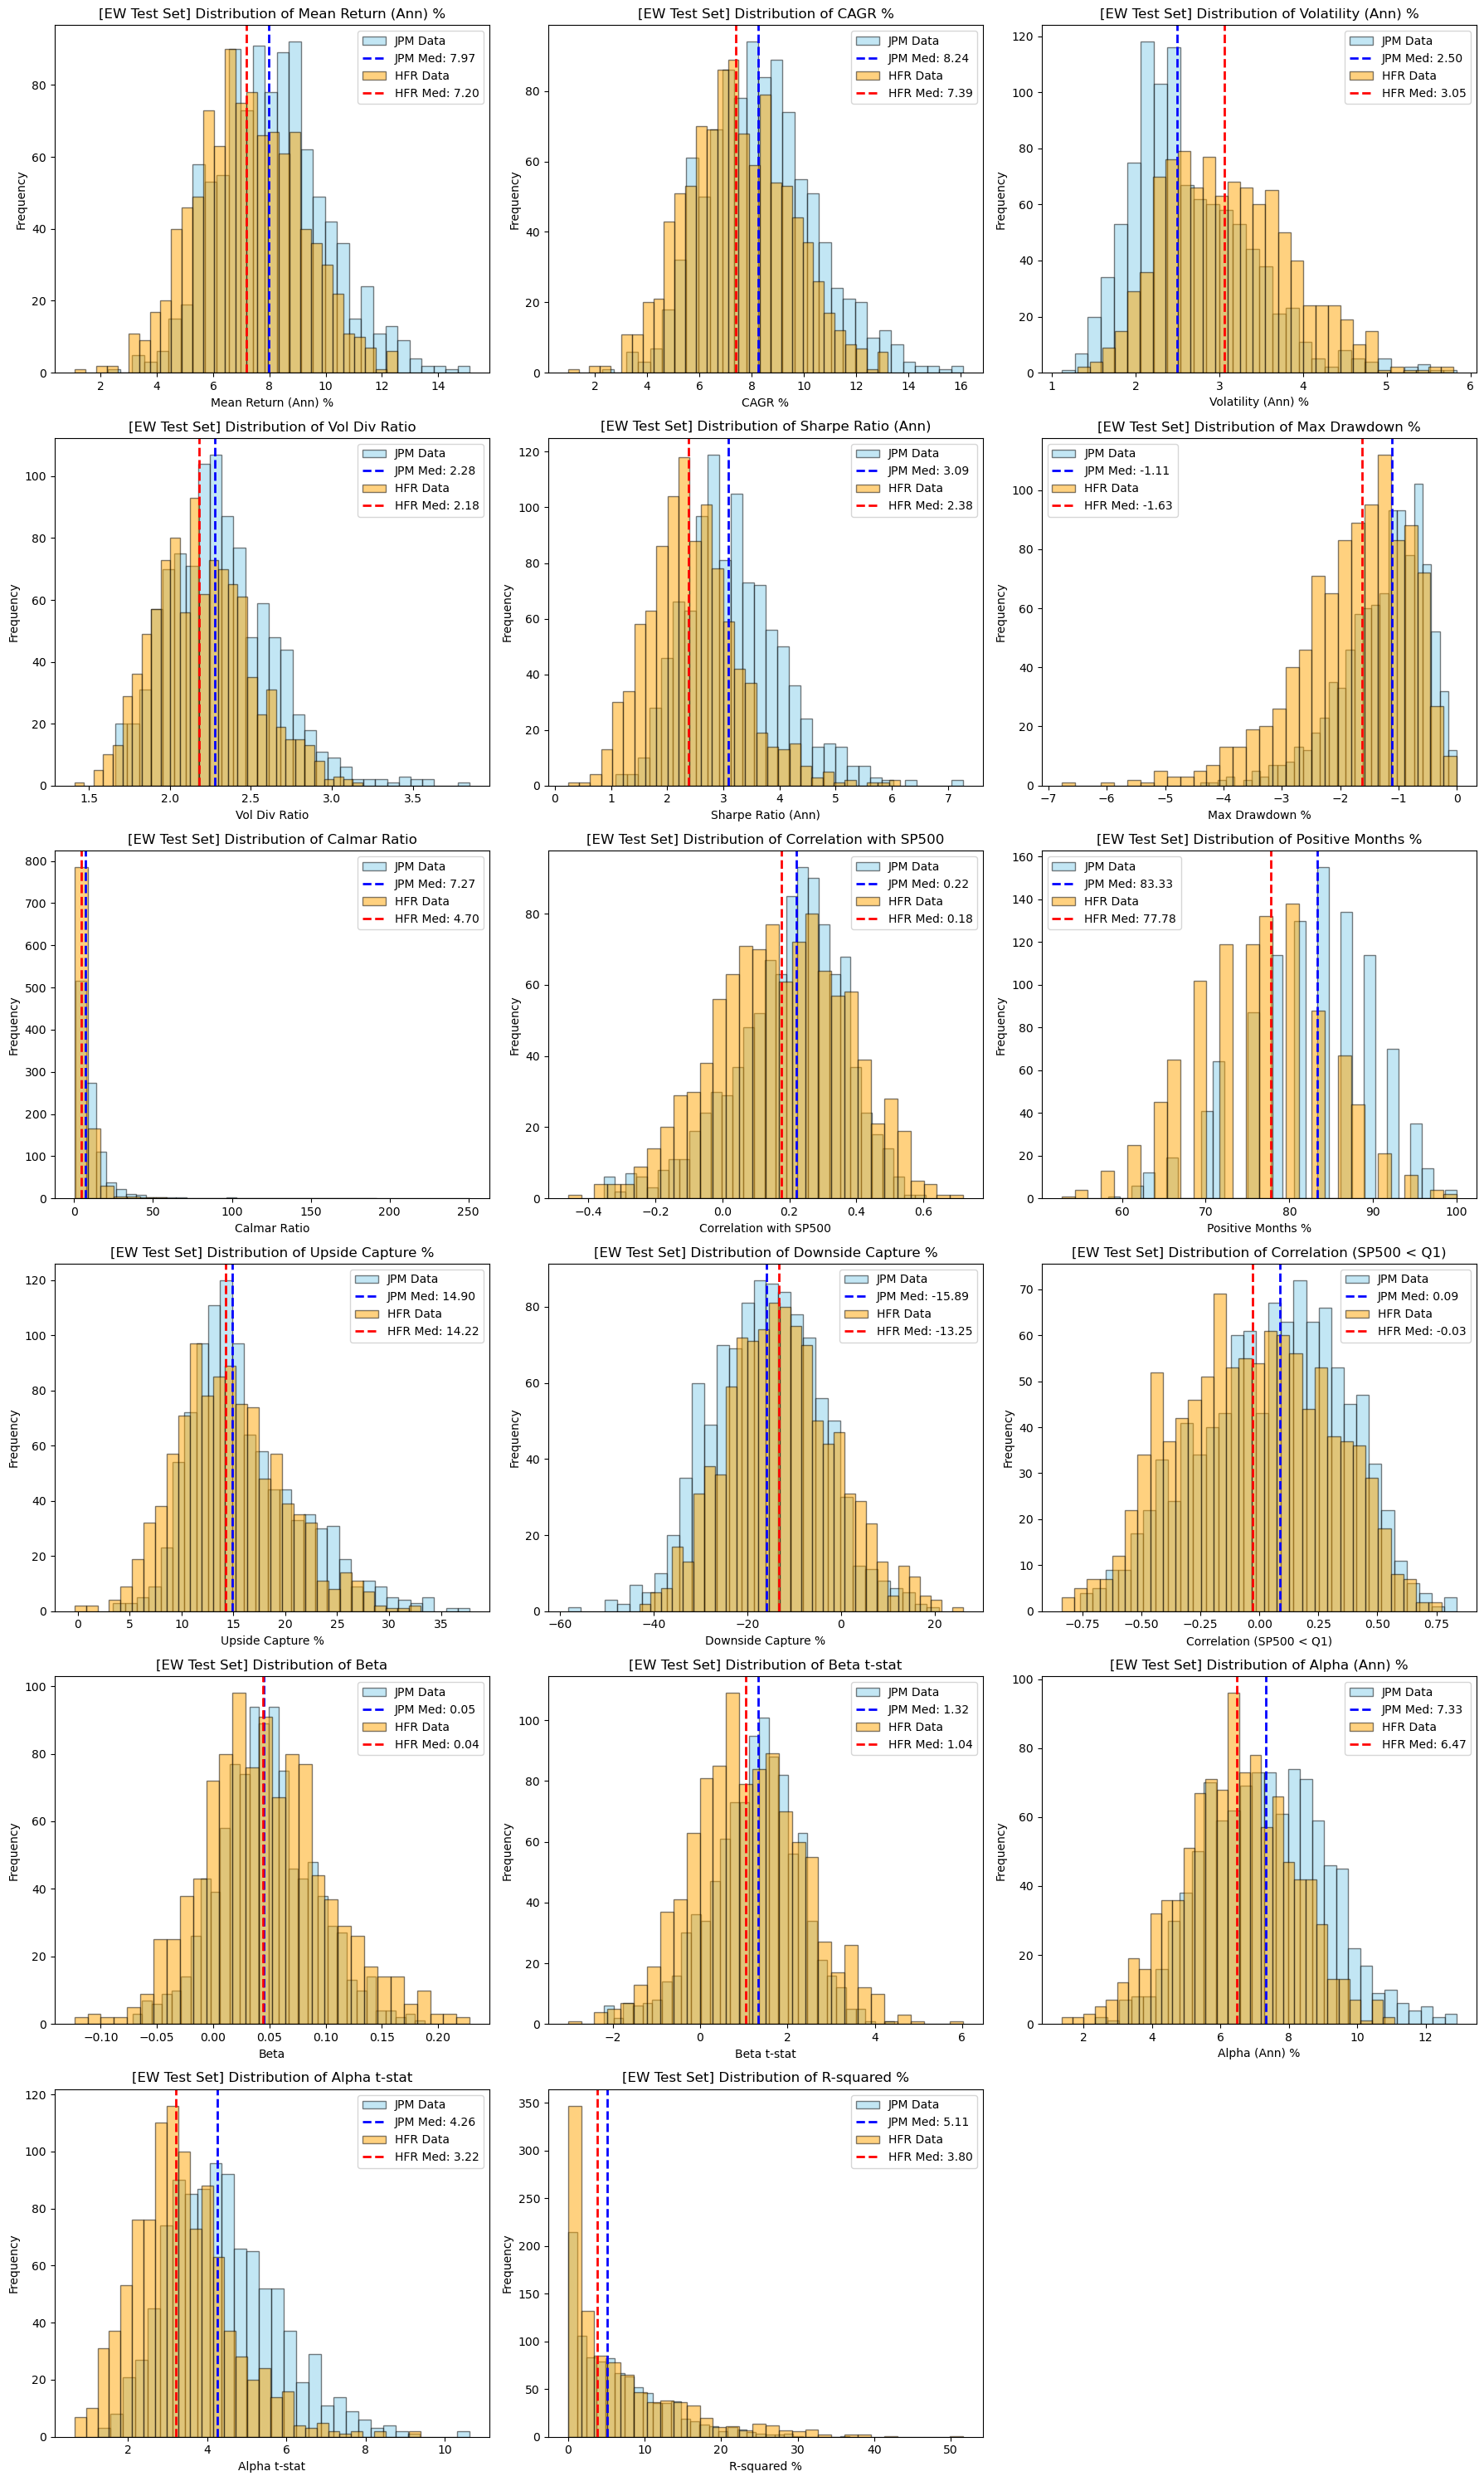

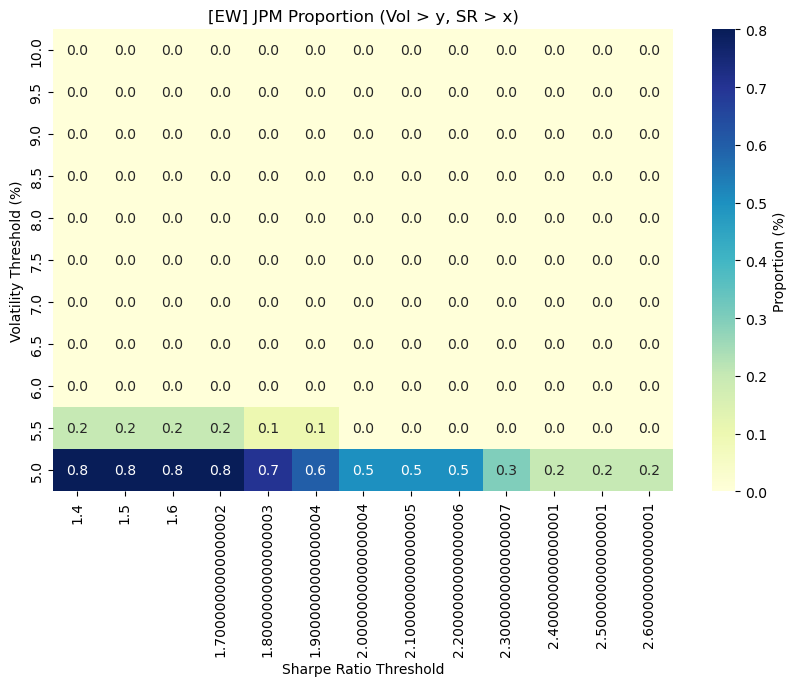

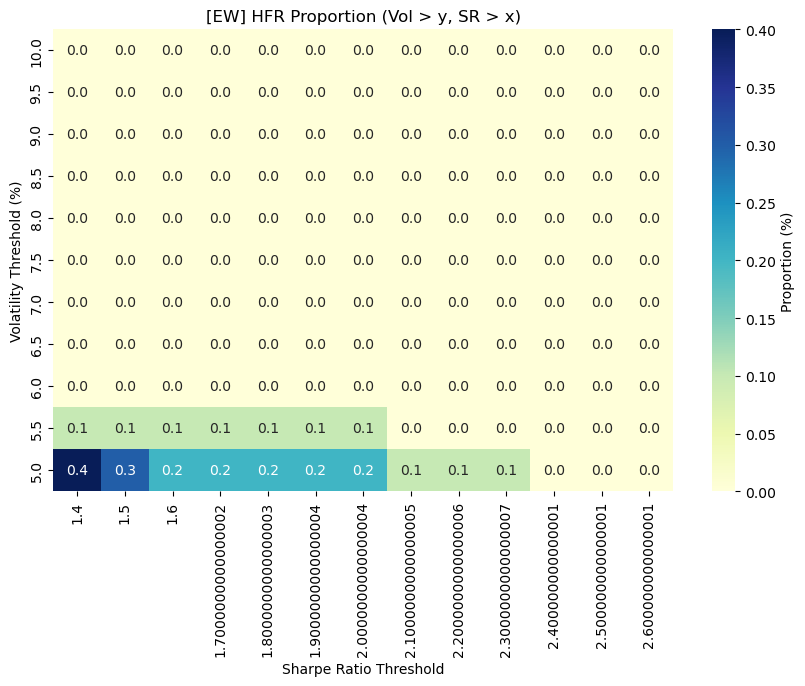

In [32]:
np.random.seed(42)
res_jpm_10_ew = run_bootstrap_n(jpm_test, sp500_test, 10, n_boot=1000, weight_scheme='ew')
res_hfr_10_ew = run_bootstrap_n(hfr_test, sp500_test, 10, n_boot=1000, weight_scheme='ew')

plot_distributions(res_jpm_10_ew, res_hfr_10_ew, title_prefix="[EW Test Set]")

run_grid_searches(res_jpm_10_ew, res_hfr_10_ew, label_1='JPM', label_2='HFR', title_prefix='[EW]')


In [33]:
np.random.seed(42)
df_q_jpm_ew, df_q_hfr_ew = run_scaling_analysis(jpm_test, hfr_test, sp500_test, weight_scheme='ew')
plot_scaling(df_q_jpm_ew, df_q_hfr_ew, title_prefix="[EW Test Set]")


Scaling sizes (EW):  92%|█████████▏| 12/13 [00:30<00:02,  2.56s/it]


KeyboardInterrupt: 

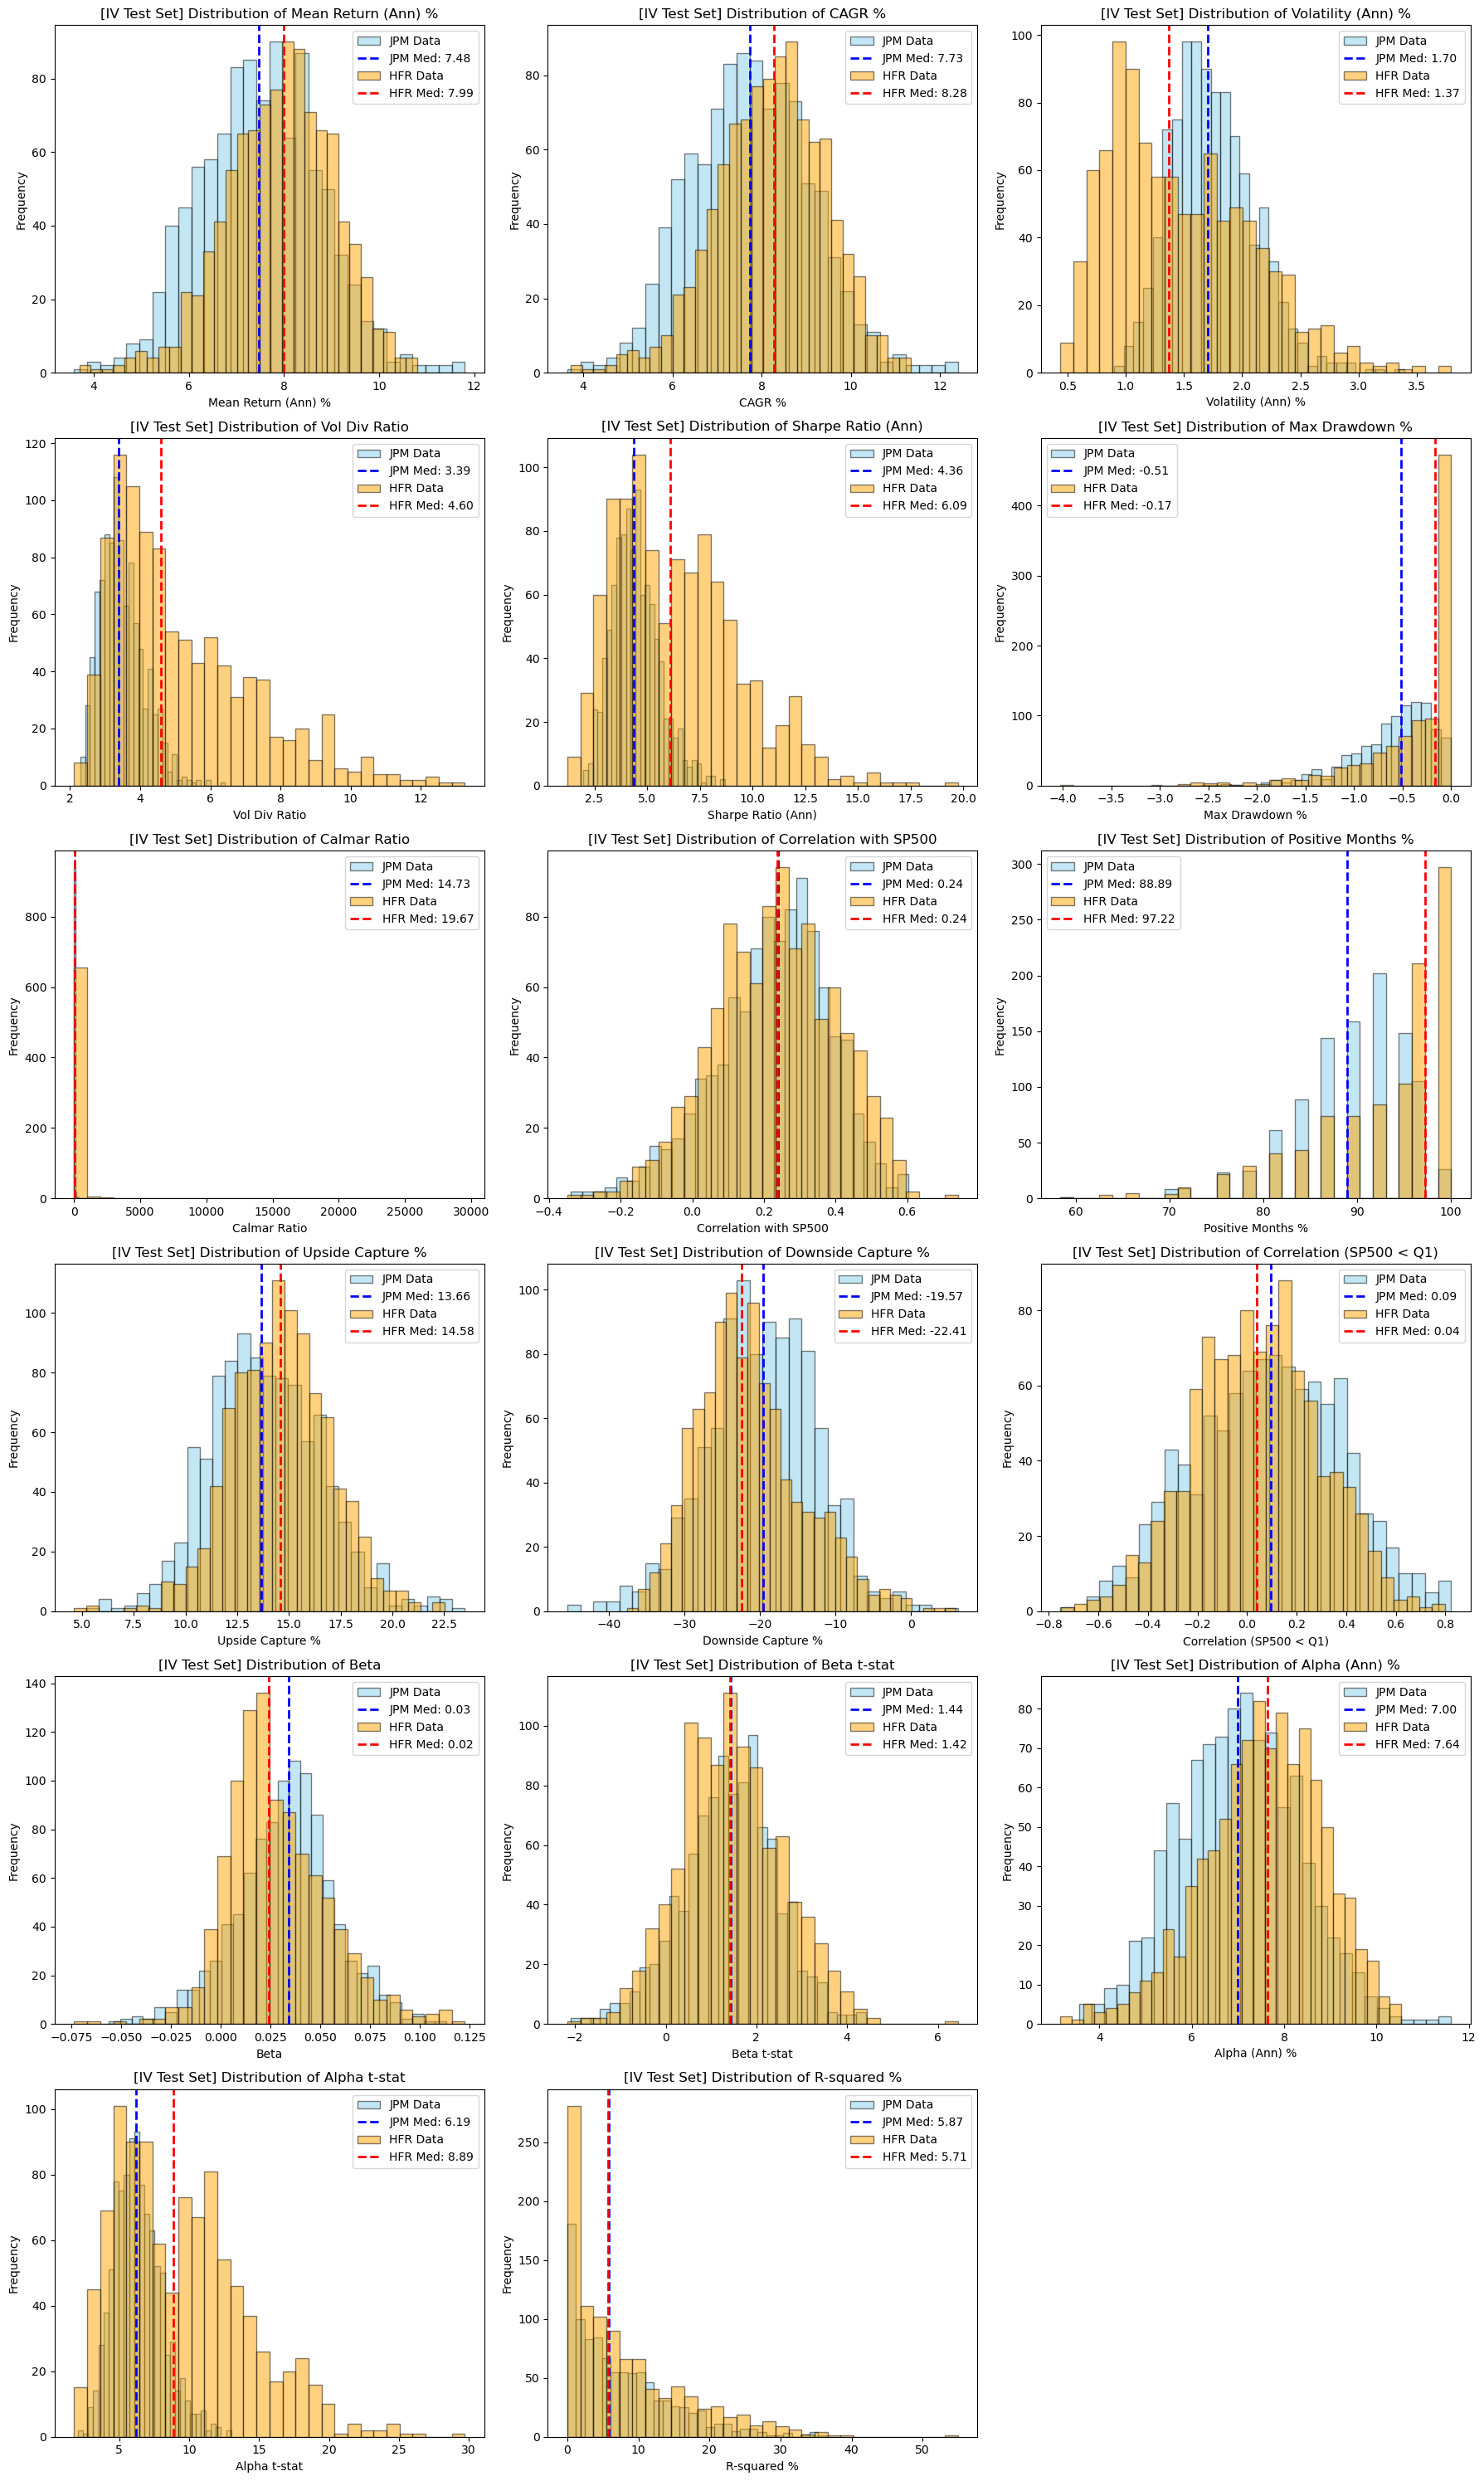

In [ ]:
np.random.seed(42)
res_jpm_10_iv = run_bootstrap_n(jpm_test, sp500_test, 10, n_boot=1000, weight_scheme='iv')
res_hfr_10_iv = run_bootstrap_n(hfr_test, sp500_test, 10, n_boot=1000, weight_scheme='iv')

plot_distributions(res_jpm_10_iv, res_hfr_10_iv, title_prefix="[IV Test Set]")

run_grid_searches(res_jpm_10_iv, res_hfr_10_iv, label_1='JPM', label_2='HFR', title_prefix='[IV]')


Scaling sizes (IV): 100%|██████████| 13/13 [00:39<00:00,  3.03s/it]


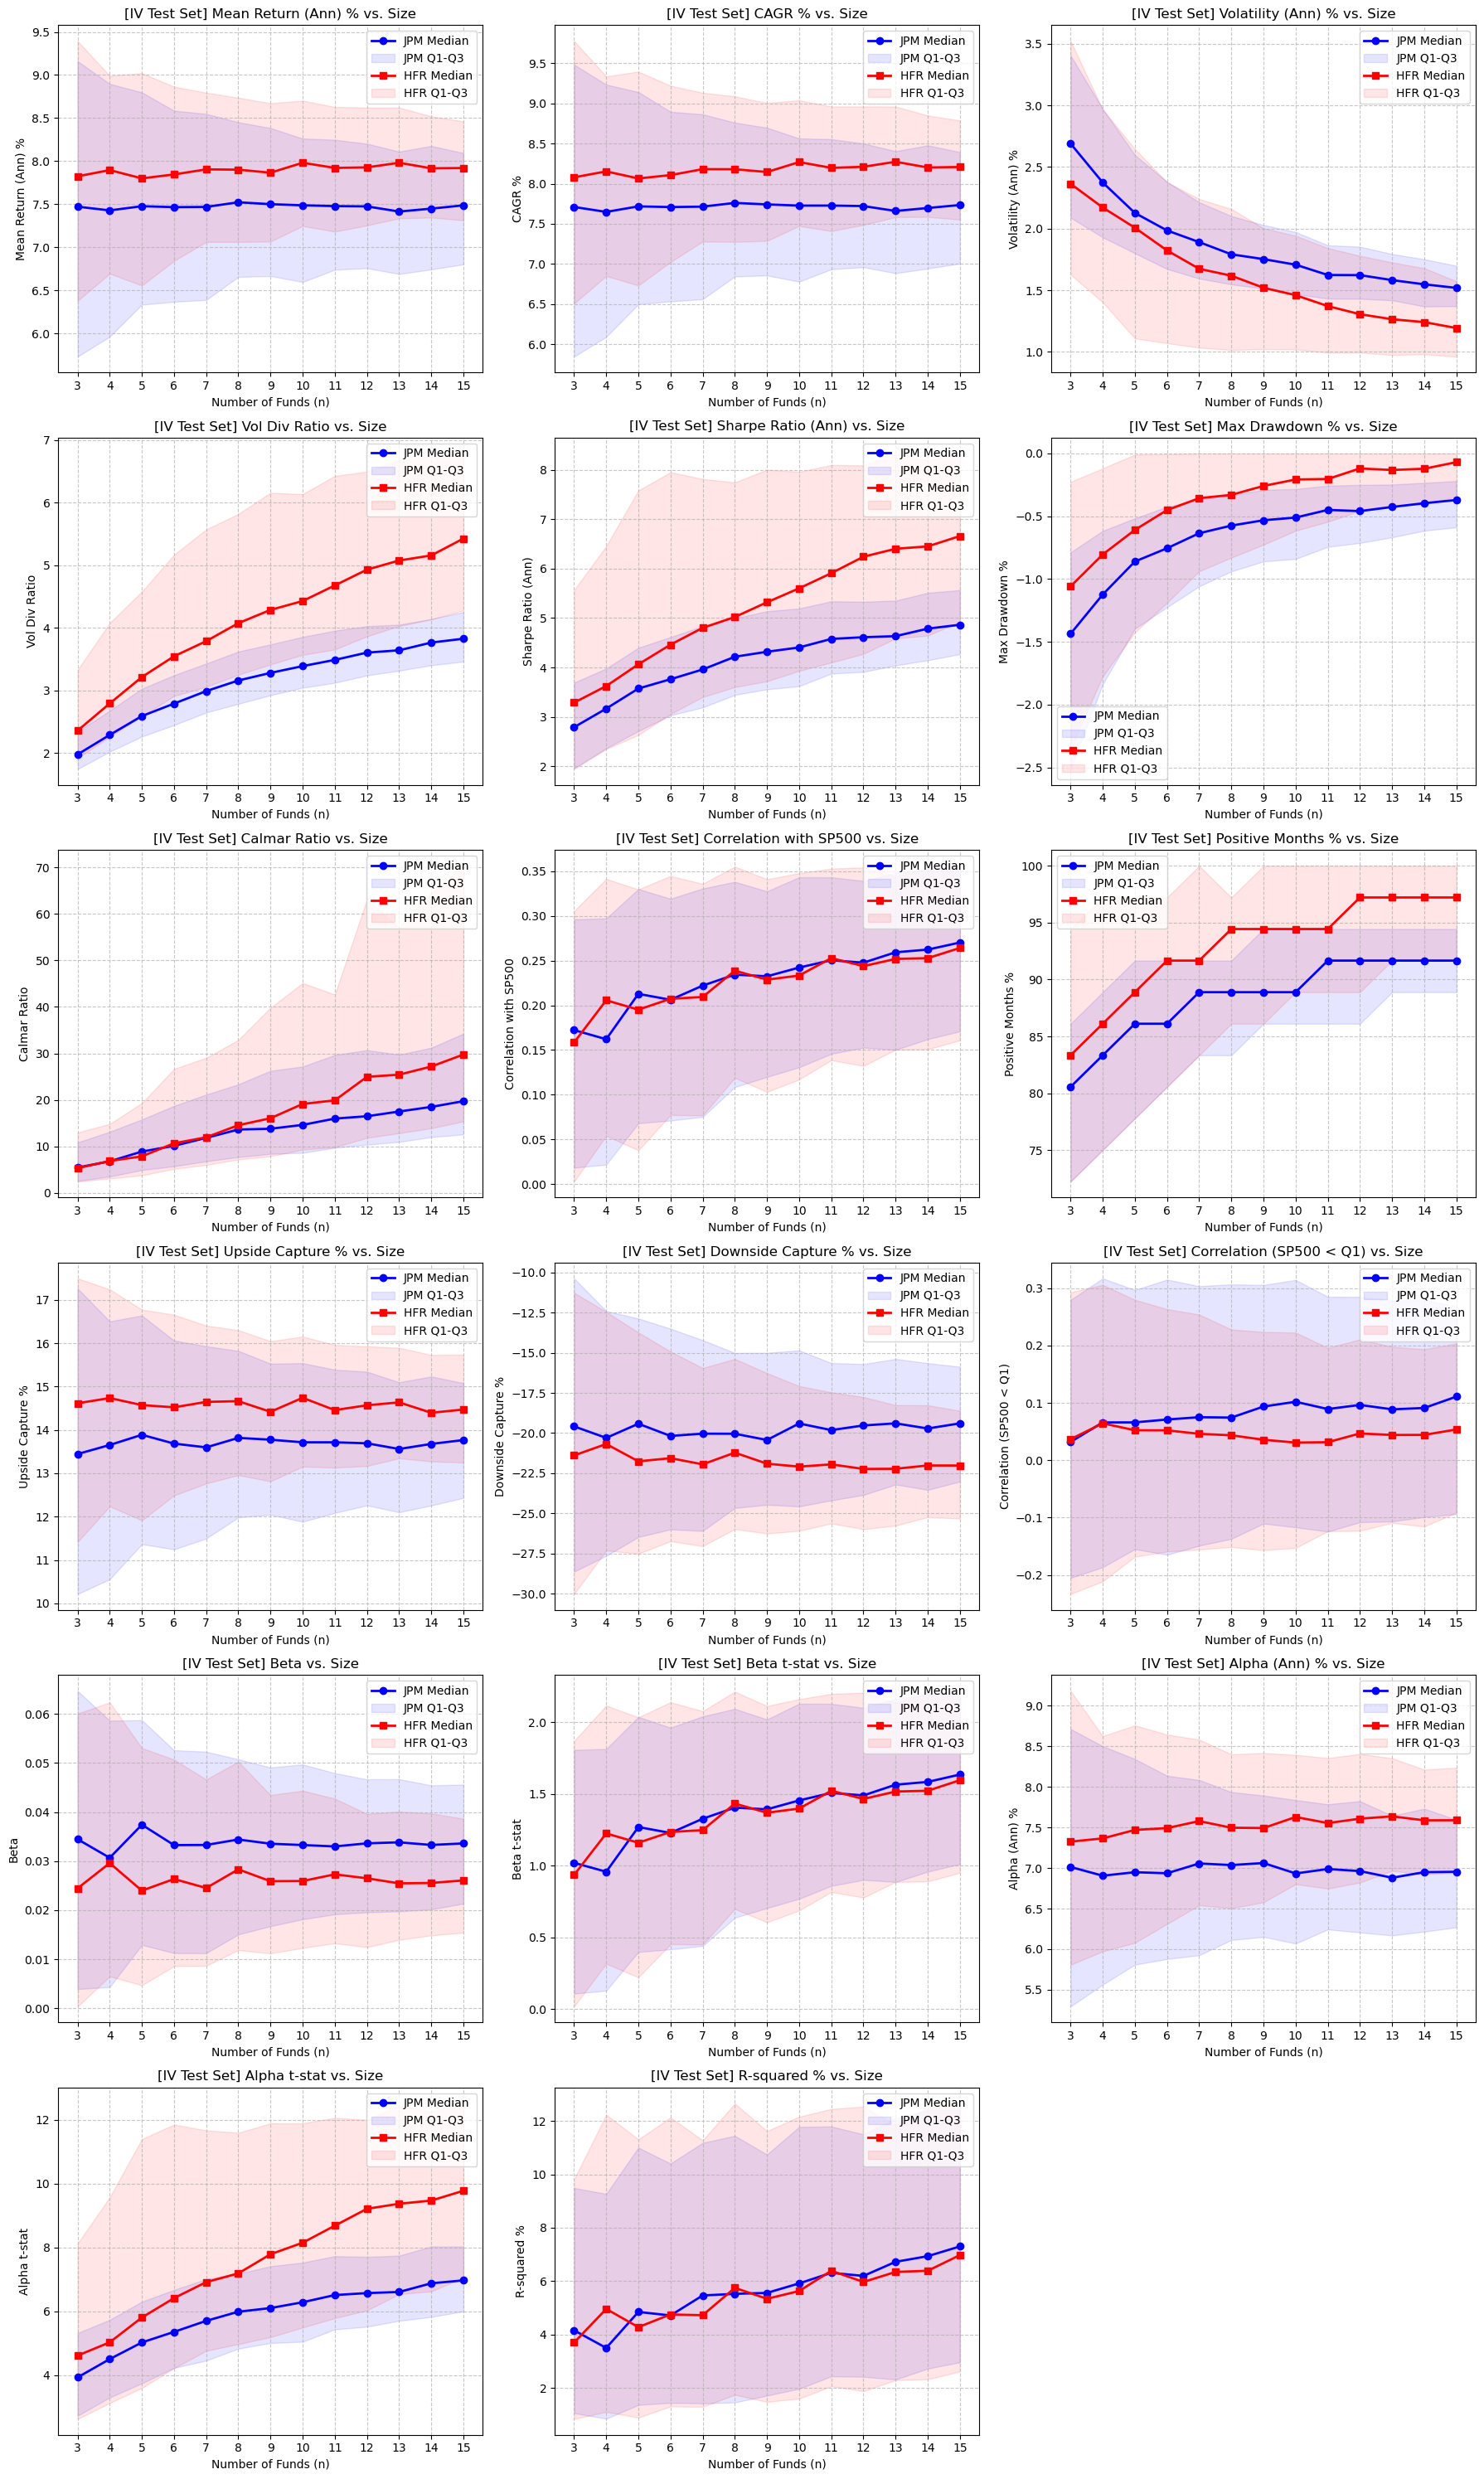

In [ ]:
np.random.seed(42)
df_q_jpm_iv, df_q_hfr_iv = run_scaling_analysis(jpm_test, hfr_test, sp500_test, weight_scheme='iv')
plot_scaling(df_q_jpm_iv, df_q_hfr_iv, title_prefix="[IV Test Set]")


In [ ]:
def create_comparison_table(res_jpm_ew, res_hfr_ew, res_jpm_iv, res_hfr_iv):
    datasets = {
        ('JPM', 'EW'): res_jpm_ew,
        ('HFR', 'EW'): res_hfr_ew,
        ('JPM', 'IV'): res_jpm_iv,
        ('HFR', 'IV'): res_hfr_iv
    }
    
    summary_data = {}
    
    for (data_name, weight_scheme), df in datasets.items():
        if df.empty:
            continue
            
        for metric in metrics_to_plot:
            q1 = df[metric].quantile(0.25)
            median = df[metric].median()
            q3 = df[metric].quantile(0.75)
            
            summary_data[(data_name, weight_scheme, 'Q1', metric)] = q1
            summary_data[(data_name, weight_scheme, 'Median', metric)] = median
            summary_data[(data_name, weight_scheme, 'Q3', metric)] = q3
            
    # Convert to a multi-index Series
    summary_series = pd.Series(summary_data)
    summary_series.index.names = ['Dataset', 'Weighting', 'Statistic', 'Metric']
    
    # Unstack the columns we want at the top
    summary_df = summary_series.unstack(level=['Dataset', 'Weighting', 'Statistic'])
    
    # Reorder columns explicitly for logical readability
    summary_df = summary_df.reindex(columns=['JPM', 'HFR'], level='Dataset')
    summary_df = summary_df.reindex(columns=['EW', 'IV'], level='Weighting')
    summary_df = summary_df.reindex(columns=['Q1', 'Median', 'Q3'], level='Statistic')
    
    # Reorder index exactly as defined in metrics_to_plot
    summary_df = summary_df.reindex(metrics_to_plot)
    
    return summary_df

comparison_table = create_comparison_table(res_jpm_10_ew, res_hfr_10_ew, res_jpm_10_iv, res_hfr_10_iv)

# Display standard formatted table
display(comparison_table)


Dataset                         JPM                                   \
Weighting                        EW                               IV   
Statistic                        Q1     Median         Q3         Q1   
Metric                                                                 
Mean Return (Ann) %        6.721486   7.971818   9.255632   6.621314   
CAGR %                     6.895645   8.240081   9.624355   6.810246   
Volatility (Ann) %         2.140531   2.495870   3.084246   1.491400   
Vol Div Ratio              2.079317   2.277206   2.508477   3.009006   
Sharpe Ratio (Ann)         2.585600   3.094582   3.686935   3.655868   
Max Drawdown %            -1.673802  -1.108581  -0.705821  -0.825500   
Calmar Ratio               4.581817   7.269792  12.293910   8.696176   
Correlation with SP500     0.100294   0.220835   0.311433   0.129373   
Positive Months %         77.777778  83.333333  86.111111  86.111111   
Upside Capture %          12.384461  14.897783  19.011995  11.922744   
Downside Capture %       -24.474583 -15.886786  -7.945155 -24.359603   
Correlation (SP500 < Q1)  -0.153516   0.086461   0.279258  -0.123745   
Beta                       0.019015   0.045247   0.073359   0.017810   
Beta t-stat                0.587771   1.320274   1.910988   0.760764   
Alpha (Ann) %              5.968300   7.330650   8.591216   6.127075   
Alpha t-stat               3.377769   4.262391   5.278085   5.137149   
R-squared %                1.674821   5.113472   9.931904   1.872495   

Dataset                                               HFR             \
Weighting                                              EW              
Statistic                    Median         Q3         Q1     Median   
Metric                                                                 
Mean Return (Ann) %        7.478866   8.341155   5.977083   7.195167   
CAGR %                     7.730212   8.654240   6.083980   7.392935   
Volatility (Ann) %         1.702926   1.967941   2.518601   3.054757   
Vol Div Ratio              3.386933   3.840373   1.979512   2.180042   
Sharpe Ratio (Ann)         4.360730   5.129778   1.917750   2.379472   
Max Drawdown %            -0.512073  -0.296187  -2.334682  -1.625983   
Calmar Ratio              14.731952  25.899522   2.990732   4.699948   
Correlation with SP500     0.240336   0.336560   0.039742   0.176216   
Positive Months %         88.888889  94.444444  69.444444  77.777778   
Upside Capture %          13.663838  15.637080  11.019409  14.218750   
Downside Capture %       -19.565298 -14.770912 -20.780839 -13.248977   
Correlation (SP500 < Q1)   0.094505   0.307870  -0.265368  -0.029210   
Beta                       0.034112   0.048023   0.010017   0.043927   
Beta t-stat                1.443706   2.084047   0.231914   1.043840   
Alpha (Ann) %              6.995160   7.917521   5.362467   6.473710   
Alpha t-stat               6.189941   7.462367   2.534668   3.219306   
R-squared %                5.871076  11.327713   0.824875   3.802236   

Dataset                                                                
Weighting                                   IV                         
Statistic                        Q3         Q1     Median          Q3  
Metric                                                                 
Mean Return (Ann) %        8.567250   7.162321   7.988101    8.731799  
CAGR %                     8.853778   7.396366   8.276421    9.067936  
Volatility (Ann) %         3.632571   0.982516   1.373408    1.907685  
Vol Div Ratio              2.393102   3.601993   4.601772    6.421966  
Sharpe Ratio (Ann)         2.900182   4.058851   6.093006    8.240261  
Max Drawdown %            -1.058500  -0.584670  -0.167729    0.000000  
Calmar Ratio               7.443632   9.269357  19.674185   49.840676  
Correlation with SP500     0.317750   0.113880   0.236919    0.354353  
Positive Months %         80.555556  88.888889  97.222222  100.000000  
Upside Capture %          17.894435  1

## 7. Whole Universe Baseline (2023-2025)

In [ ]:
# Slice global data for the test period (Whole Universe)
jpm_test_universe = jpm_period.loc[test_start:test_end]
hfr_test_universe = hfr_period.loc[test_start:test_end]

print(f"JPM Universe Test Set Shape: {jpm_test_universe.shape}")
print(f"HFR Universe Test Set Shape: {hfr_test_universe.shape}")

np.random.seed(42)
# EW Bootstrap for Universe
res_jpm_10_ew_universe = run_bootstrap_n(jpm_test_universe, sp500_test, 10, n_boot=1000, weight_scheme='ew')
res_hfr_10_ew_universe = run_bootstrap_n(hfr_test_universe, sp500_test, 10, n_boot=1000, weight_scheme='ew')

np.random.seed(42)
# IV Bootstrap for Universe
res_jpm_10_iv_universe = run_bootstrap_n(jpm_test_universe, sp500_test, 10, n_boot=1000, weight_scheme='iv')
res_hfr_10_iv_universe = run_bootstrap_n(hfr_test_universe, sp500_test, 10, n_boot=1000, weight_scheme='iv')


JPM Universe Test Set Shape: (36, 348)
HFR Universe Test Set Shape: (36, 354)


In [ ]:
def plot_universe_comparison_box(res_sel, res_uni, dataset_name, weight_scheme):
    n_metrics = len(metrics_to_plot)
    nrows = int(np.ceil(n_metrics / 3))
    fig, axes = plt.subplots(nrows, 3, figsize=(18, 5 * nrows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        
        data_to_plot = []
        labels = []
        
        if not res_sel.empty:
            data_to_plot.append(res_sel[metric].dropna().values)
            labels.append("Top 20%")
            
        if not res_uni.empty:
            data_to_plot.append(res_uni[metric].dropna().values)
            labels.append("Universe")
            
        if data_to_plot:
            sns.boxplot(data=data_to_plot, ax=ax, palette=["skyblue", "lightgray"])
            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels(labels)
            
        ax.set_title(f'{dataset_name} [{weight_scheme.upper()}] - {metric}')
        ax.set_ylabel(metric)

    for i in range(n_metrics, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

def plot_universe_comparison_hist(res_sel, res_uni, dataset_name, weight_scheme):
    n_metrics = len(metrics_to_plot)
    nrows = int(np.ceil(n_metrics / 3))
    fig, axes = plt.subplots(nrows, 3, figsize=(18, 5 * nrows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        
        if not res_uni.empty:
            d_uni = res_uni[metric].dropna()
            ax.hist(d_uni, bins=30, color='gray', edgecolor='black', alpha=0.4, label='Universe')
            med_uni = d_uni.median()
            ax.axvline(med_uni, color='darkgray', linestyle='dashed', linewidth=2)
            
        if not res_sel.empty:
            d_sel = res_sel[metric].dropna()
            ax.hist(d_sel, bins=30, color='blue', edgecolor='black', alpha=0.5, label='Top 20%')
            med_sel = d_sel.median()
            ax.axvline(med_sel, color='blue', linestyle='dashed', linewidth=2)
            
        ax.set_title(f'{dataset_name} [{weight_scheme.upper()}] - {metric}')
        ax.set_xlabel(metric)
        ax.set_ylabel('Frequency')
        ax.legend()

    for i in range(n_metrics, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()


### Visualizations (JPM EW)

JPM EW: Top 20% vs Universe Boxplots


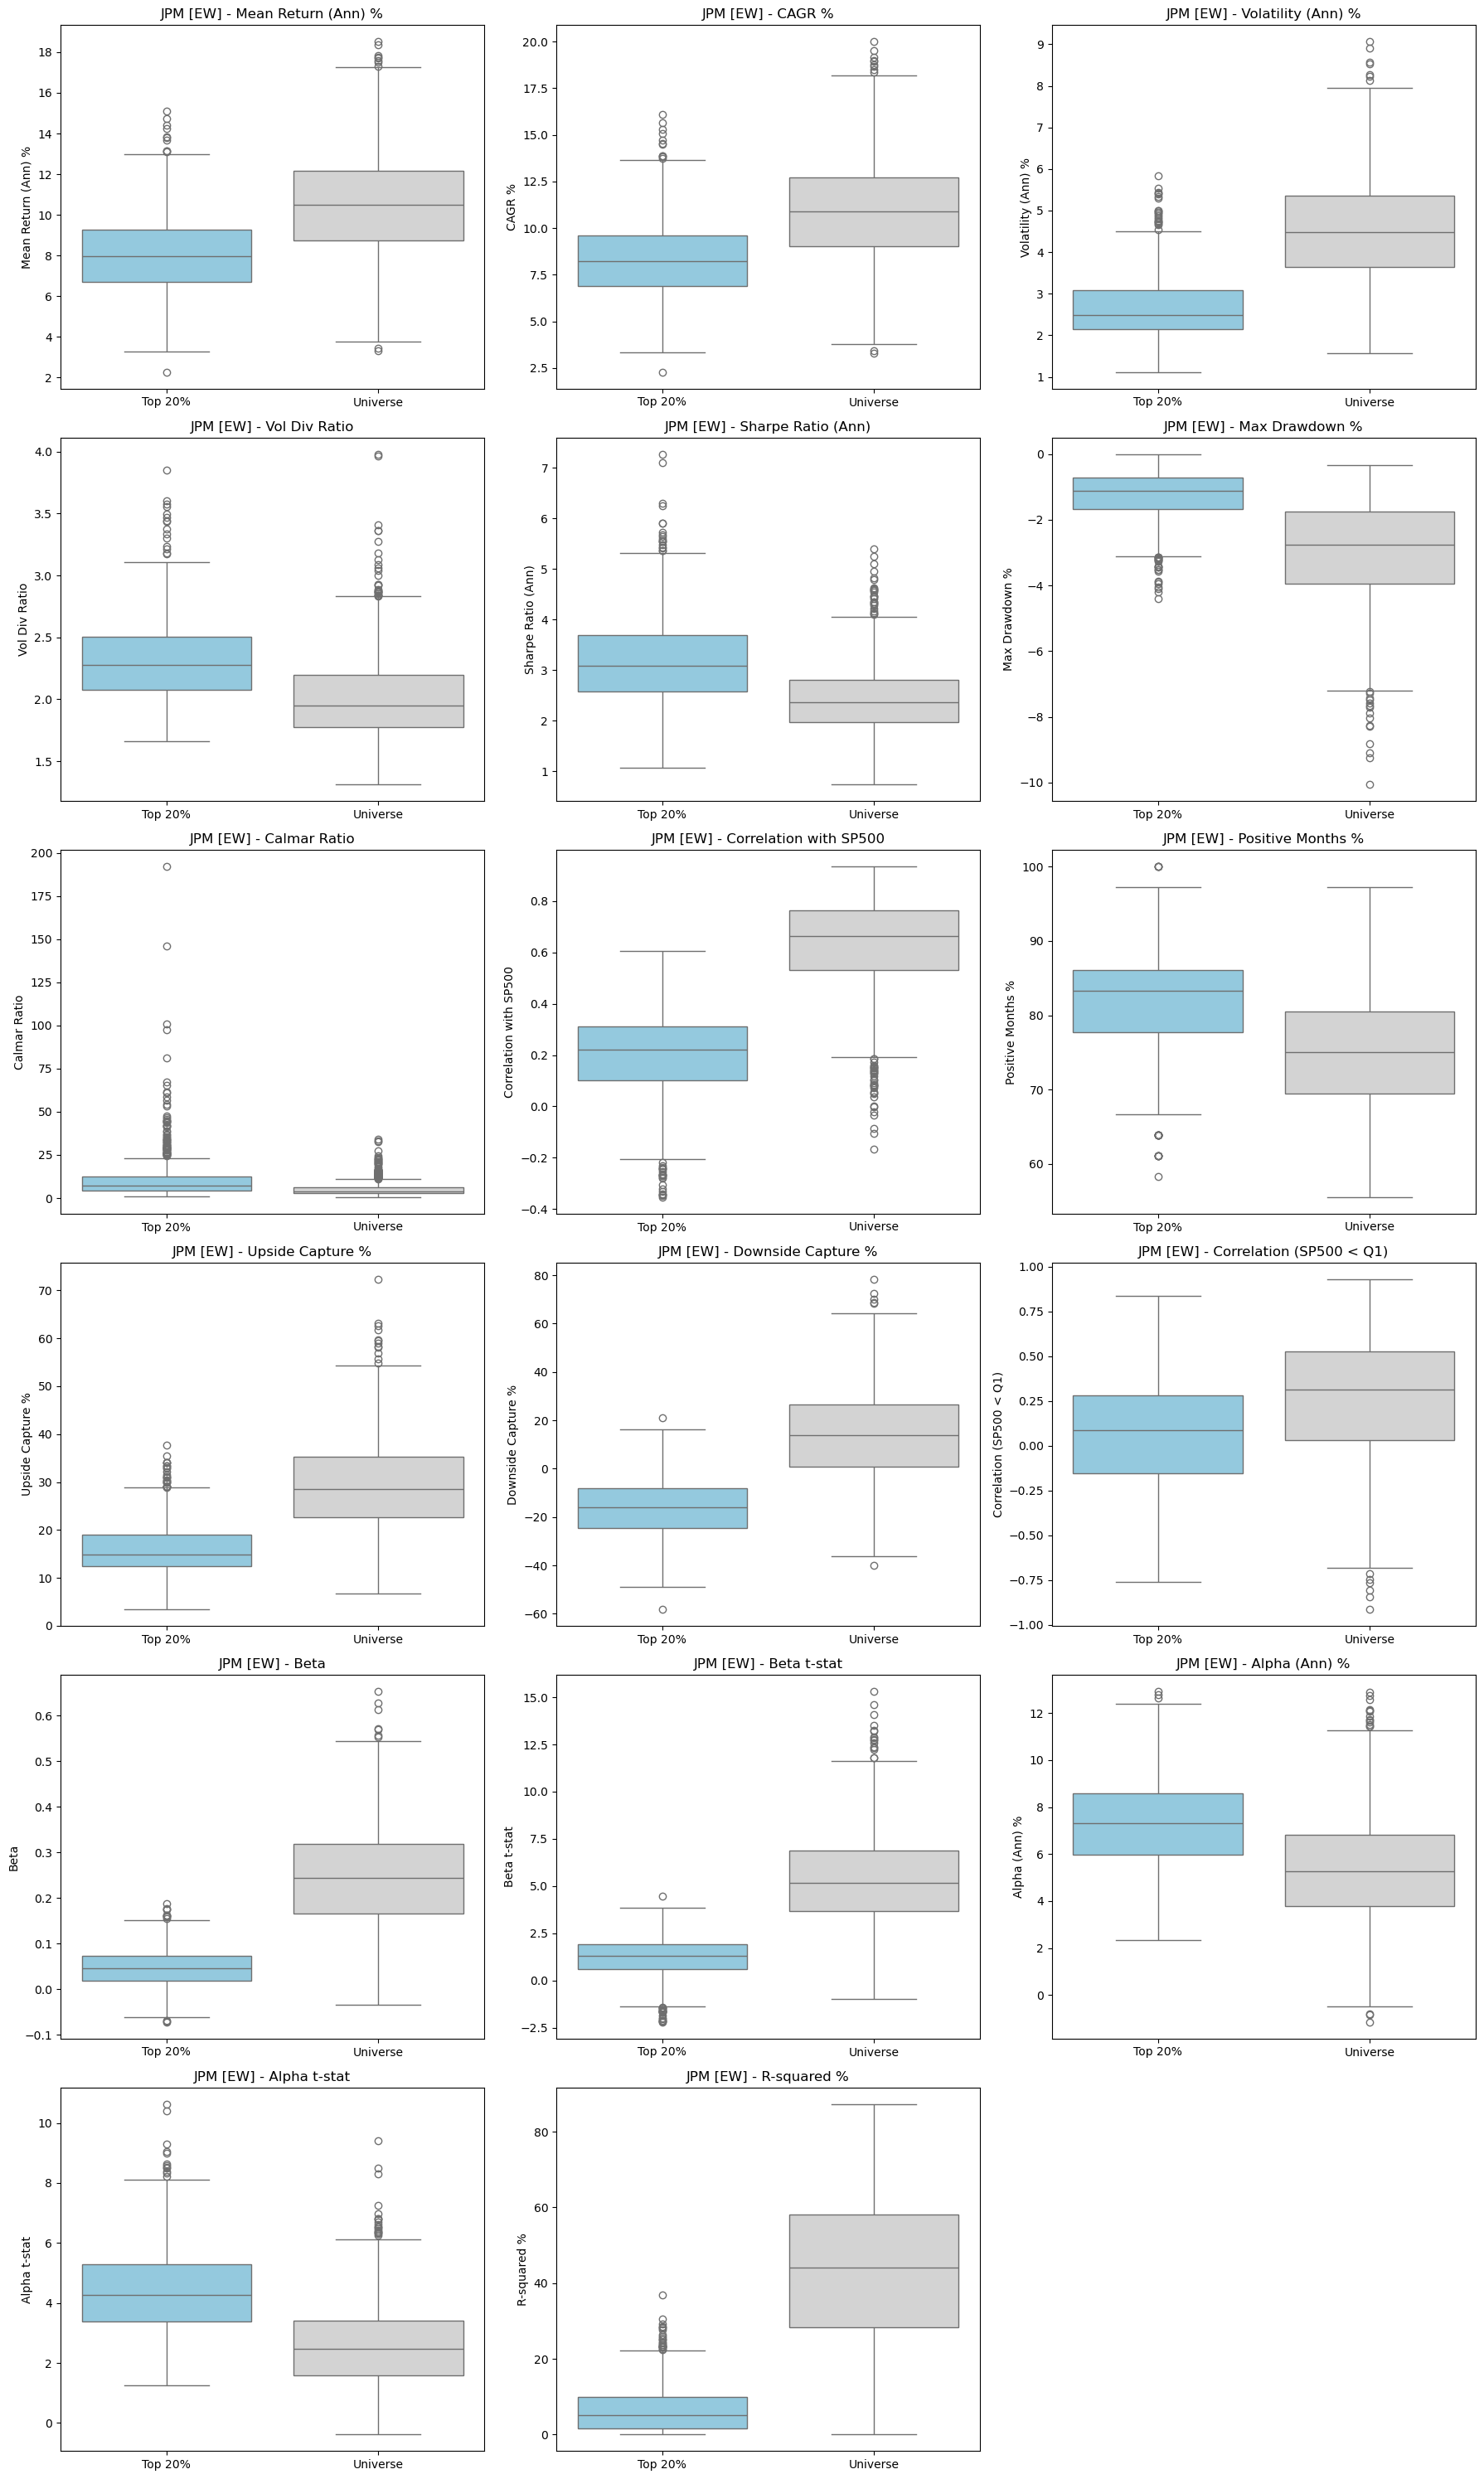

JPM EW: Top 20% vs Universe Overlaid Histograms


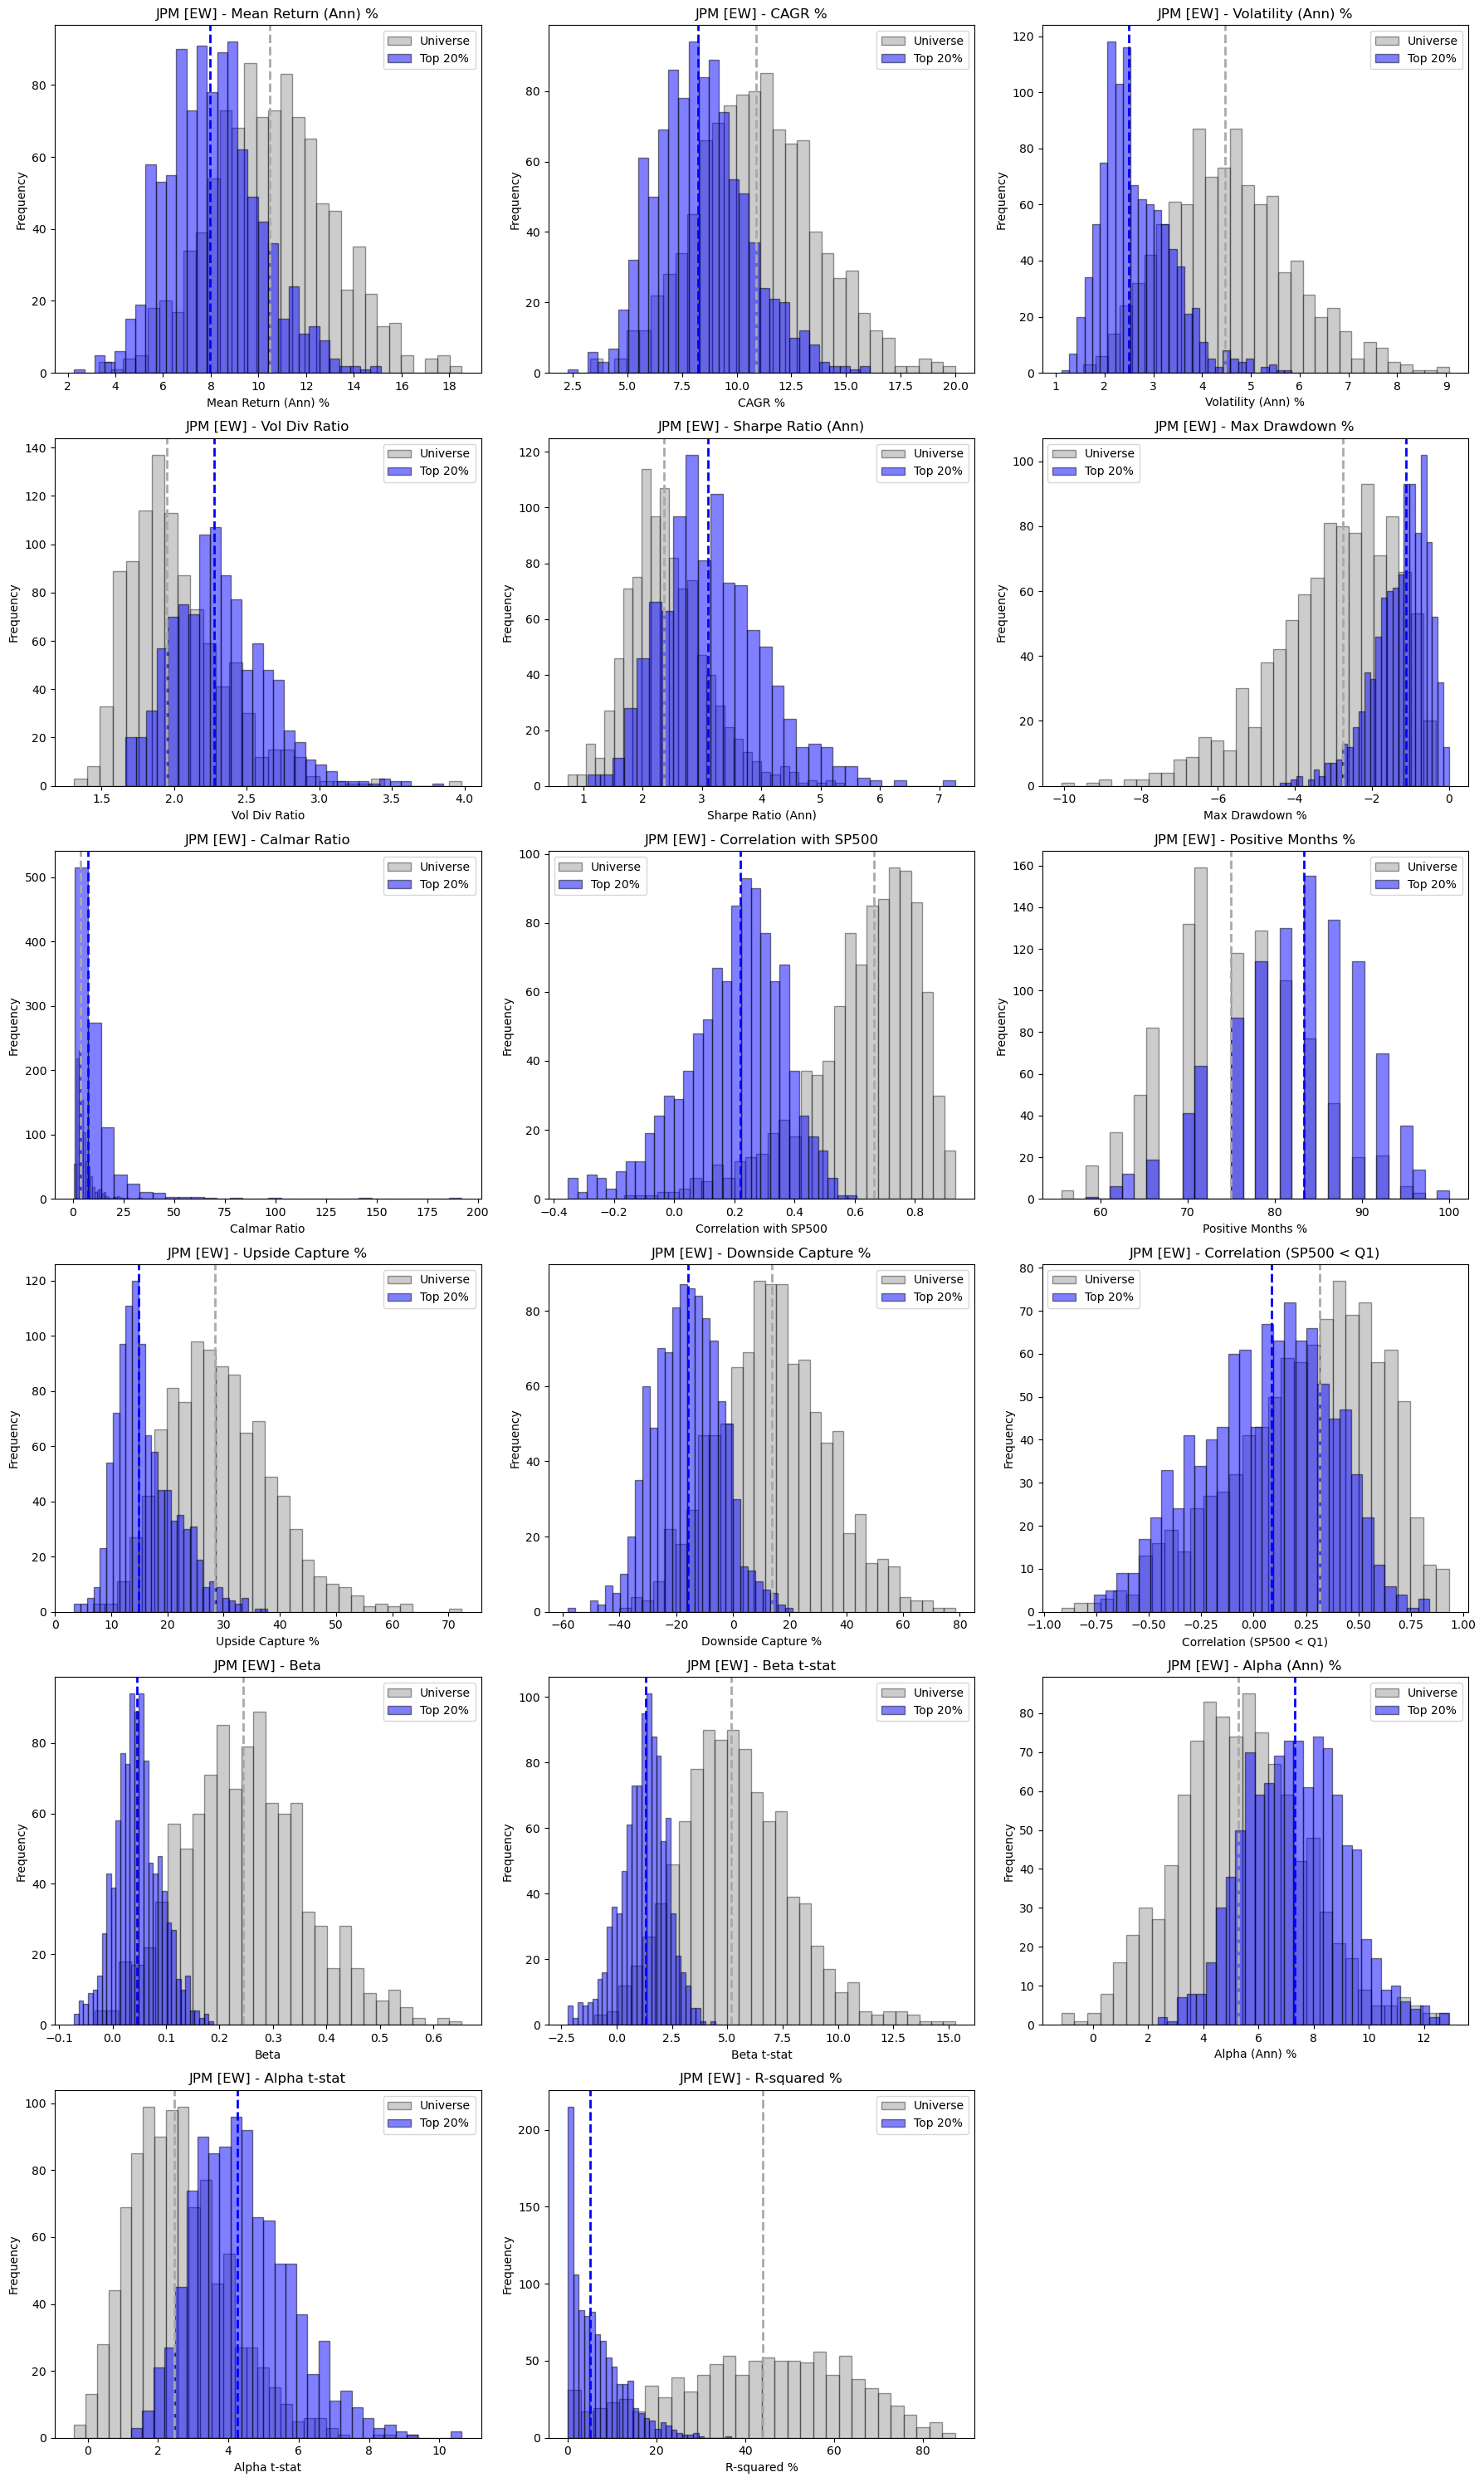

In [ ]:
print("JPM EW: Top 20% vs Universe Boxplots")
plot_universe_comparison_box(res_jpm_10_ew, res_jpm_10_ew_universe, "JPM", "EW")

print("JPM EW: Top 20% vs Universe Overlaid Histograms")
plot_universe_comparison_hist(res_jpm_10_ew, res_jpm_10_ew_universe, "JPM", "EW")


### Visualizations (HFR EW)

HFR EW: Top 20% vs Universe Boxplots


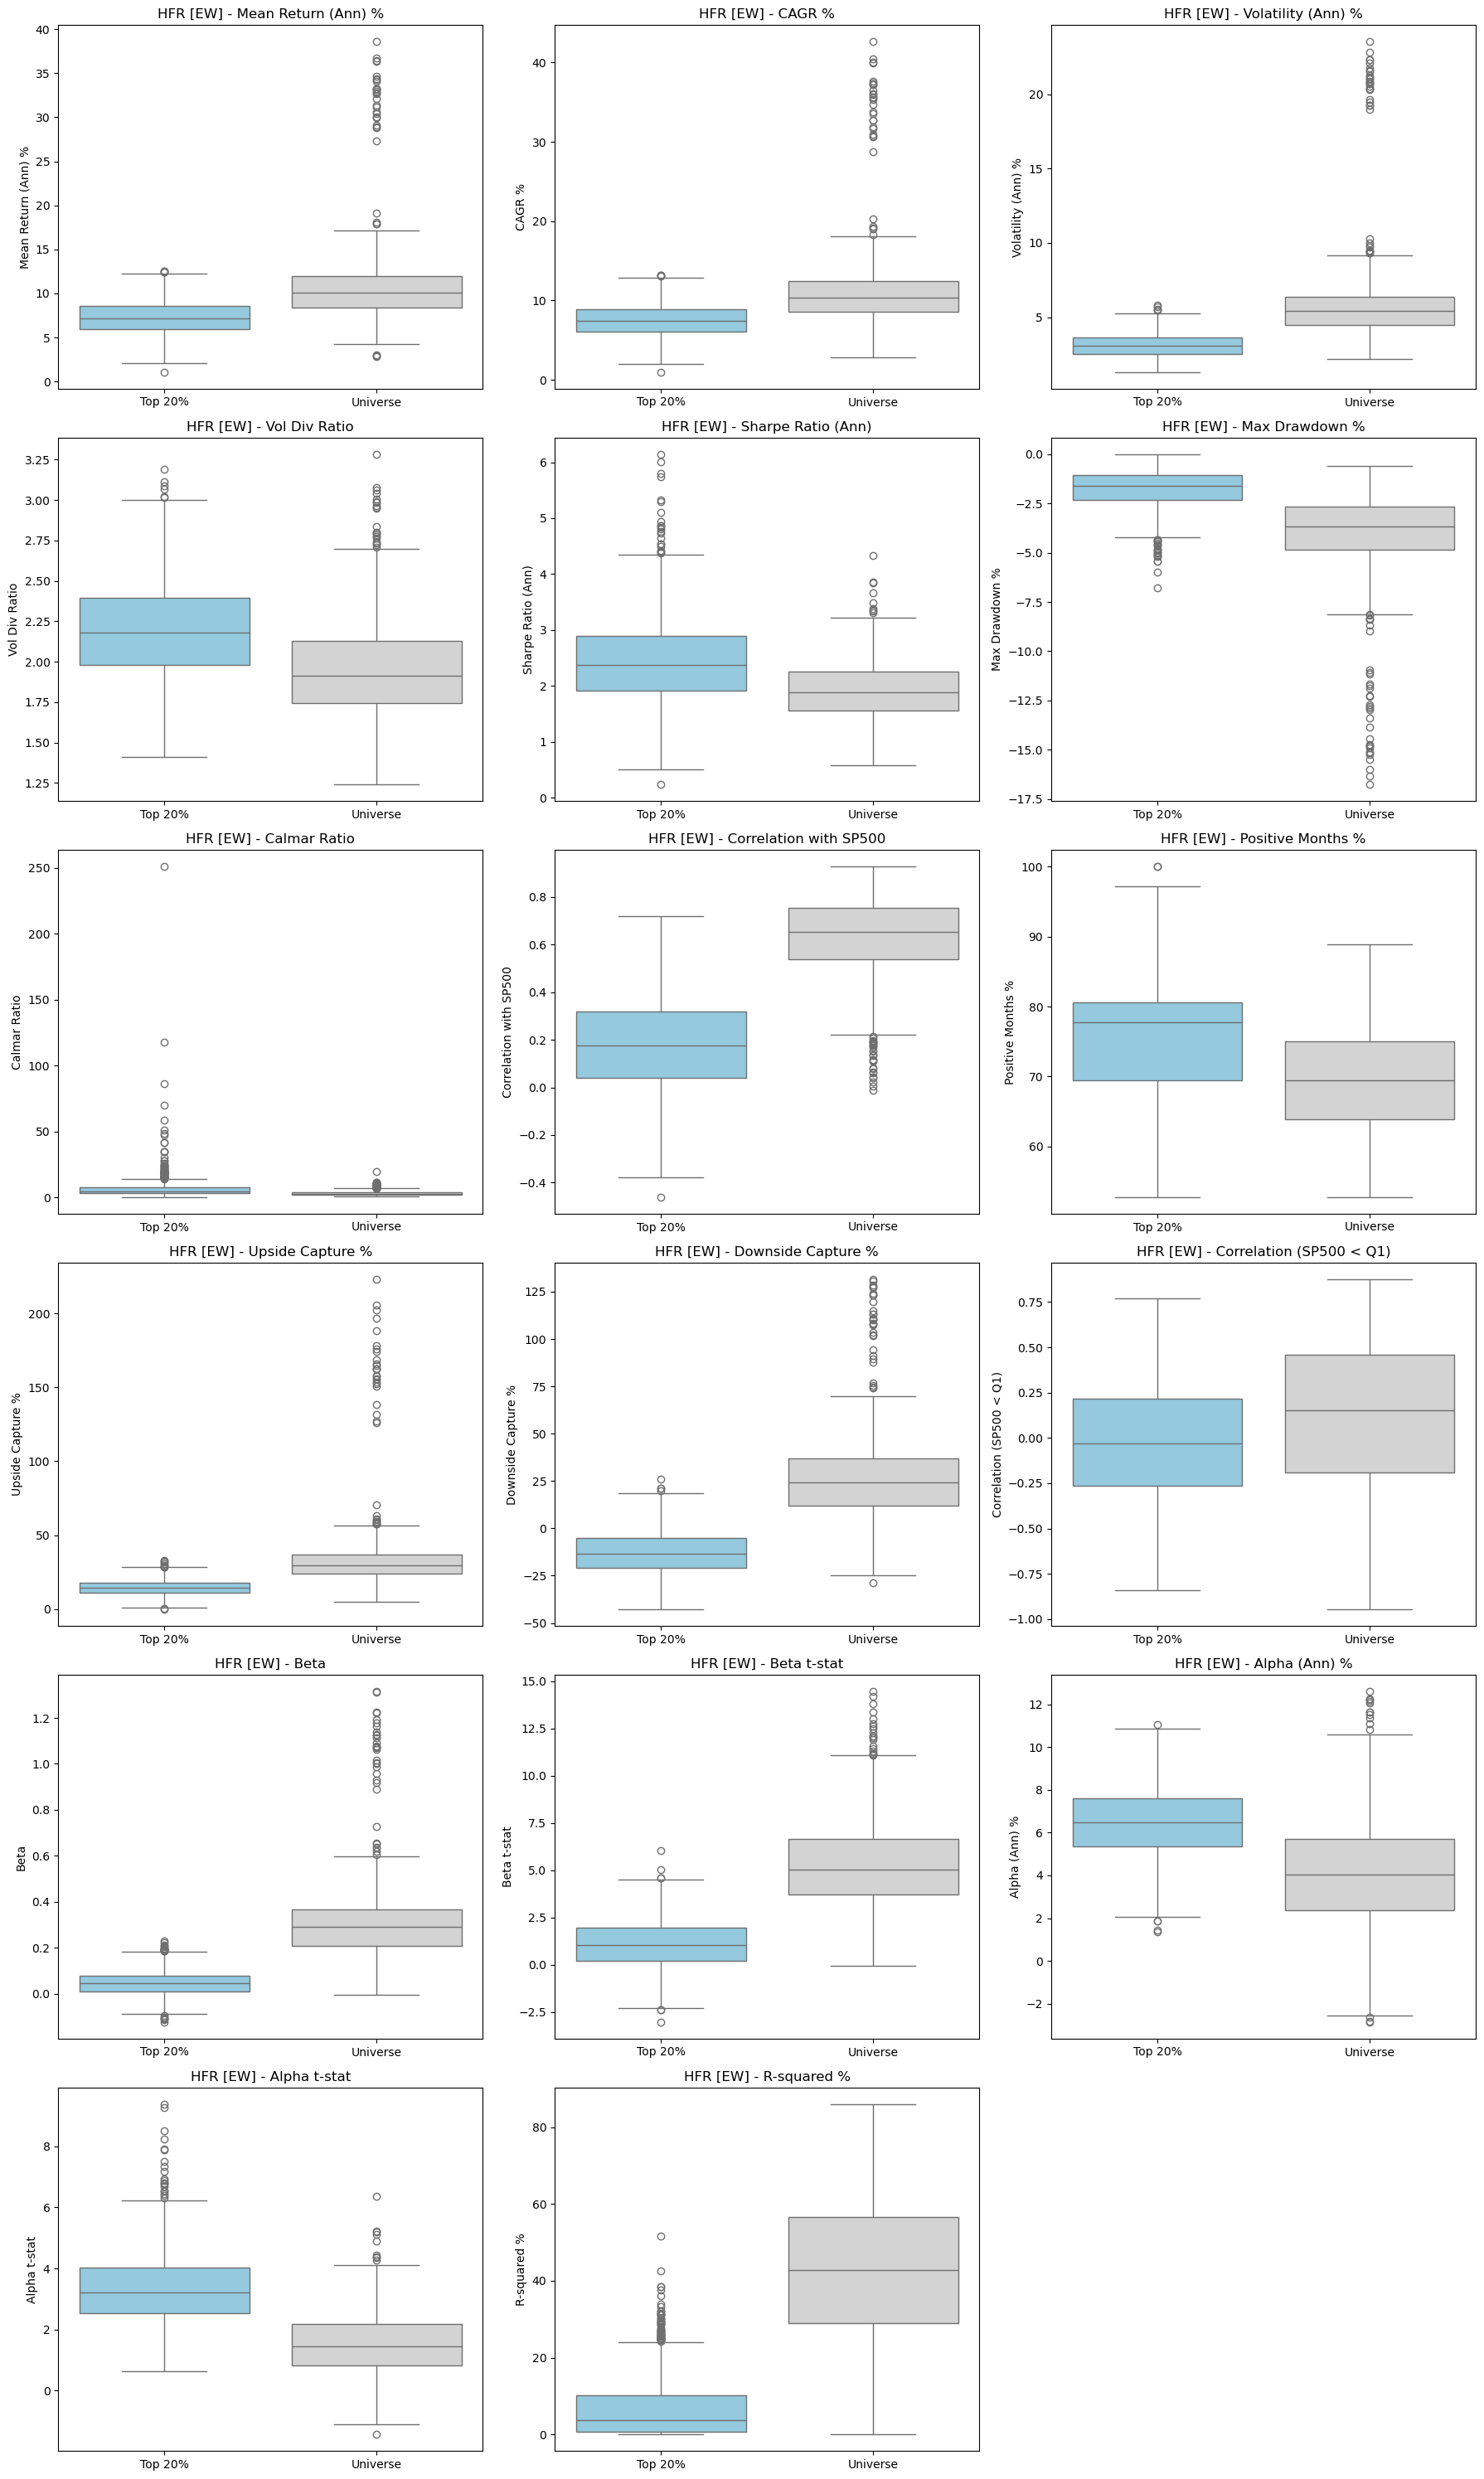

HFR EW: Top 20% vs Universe Overlaid Histograms


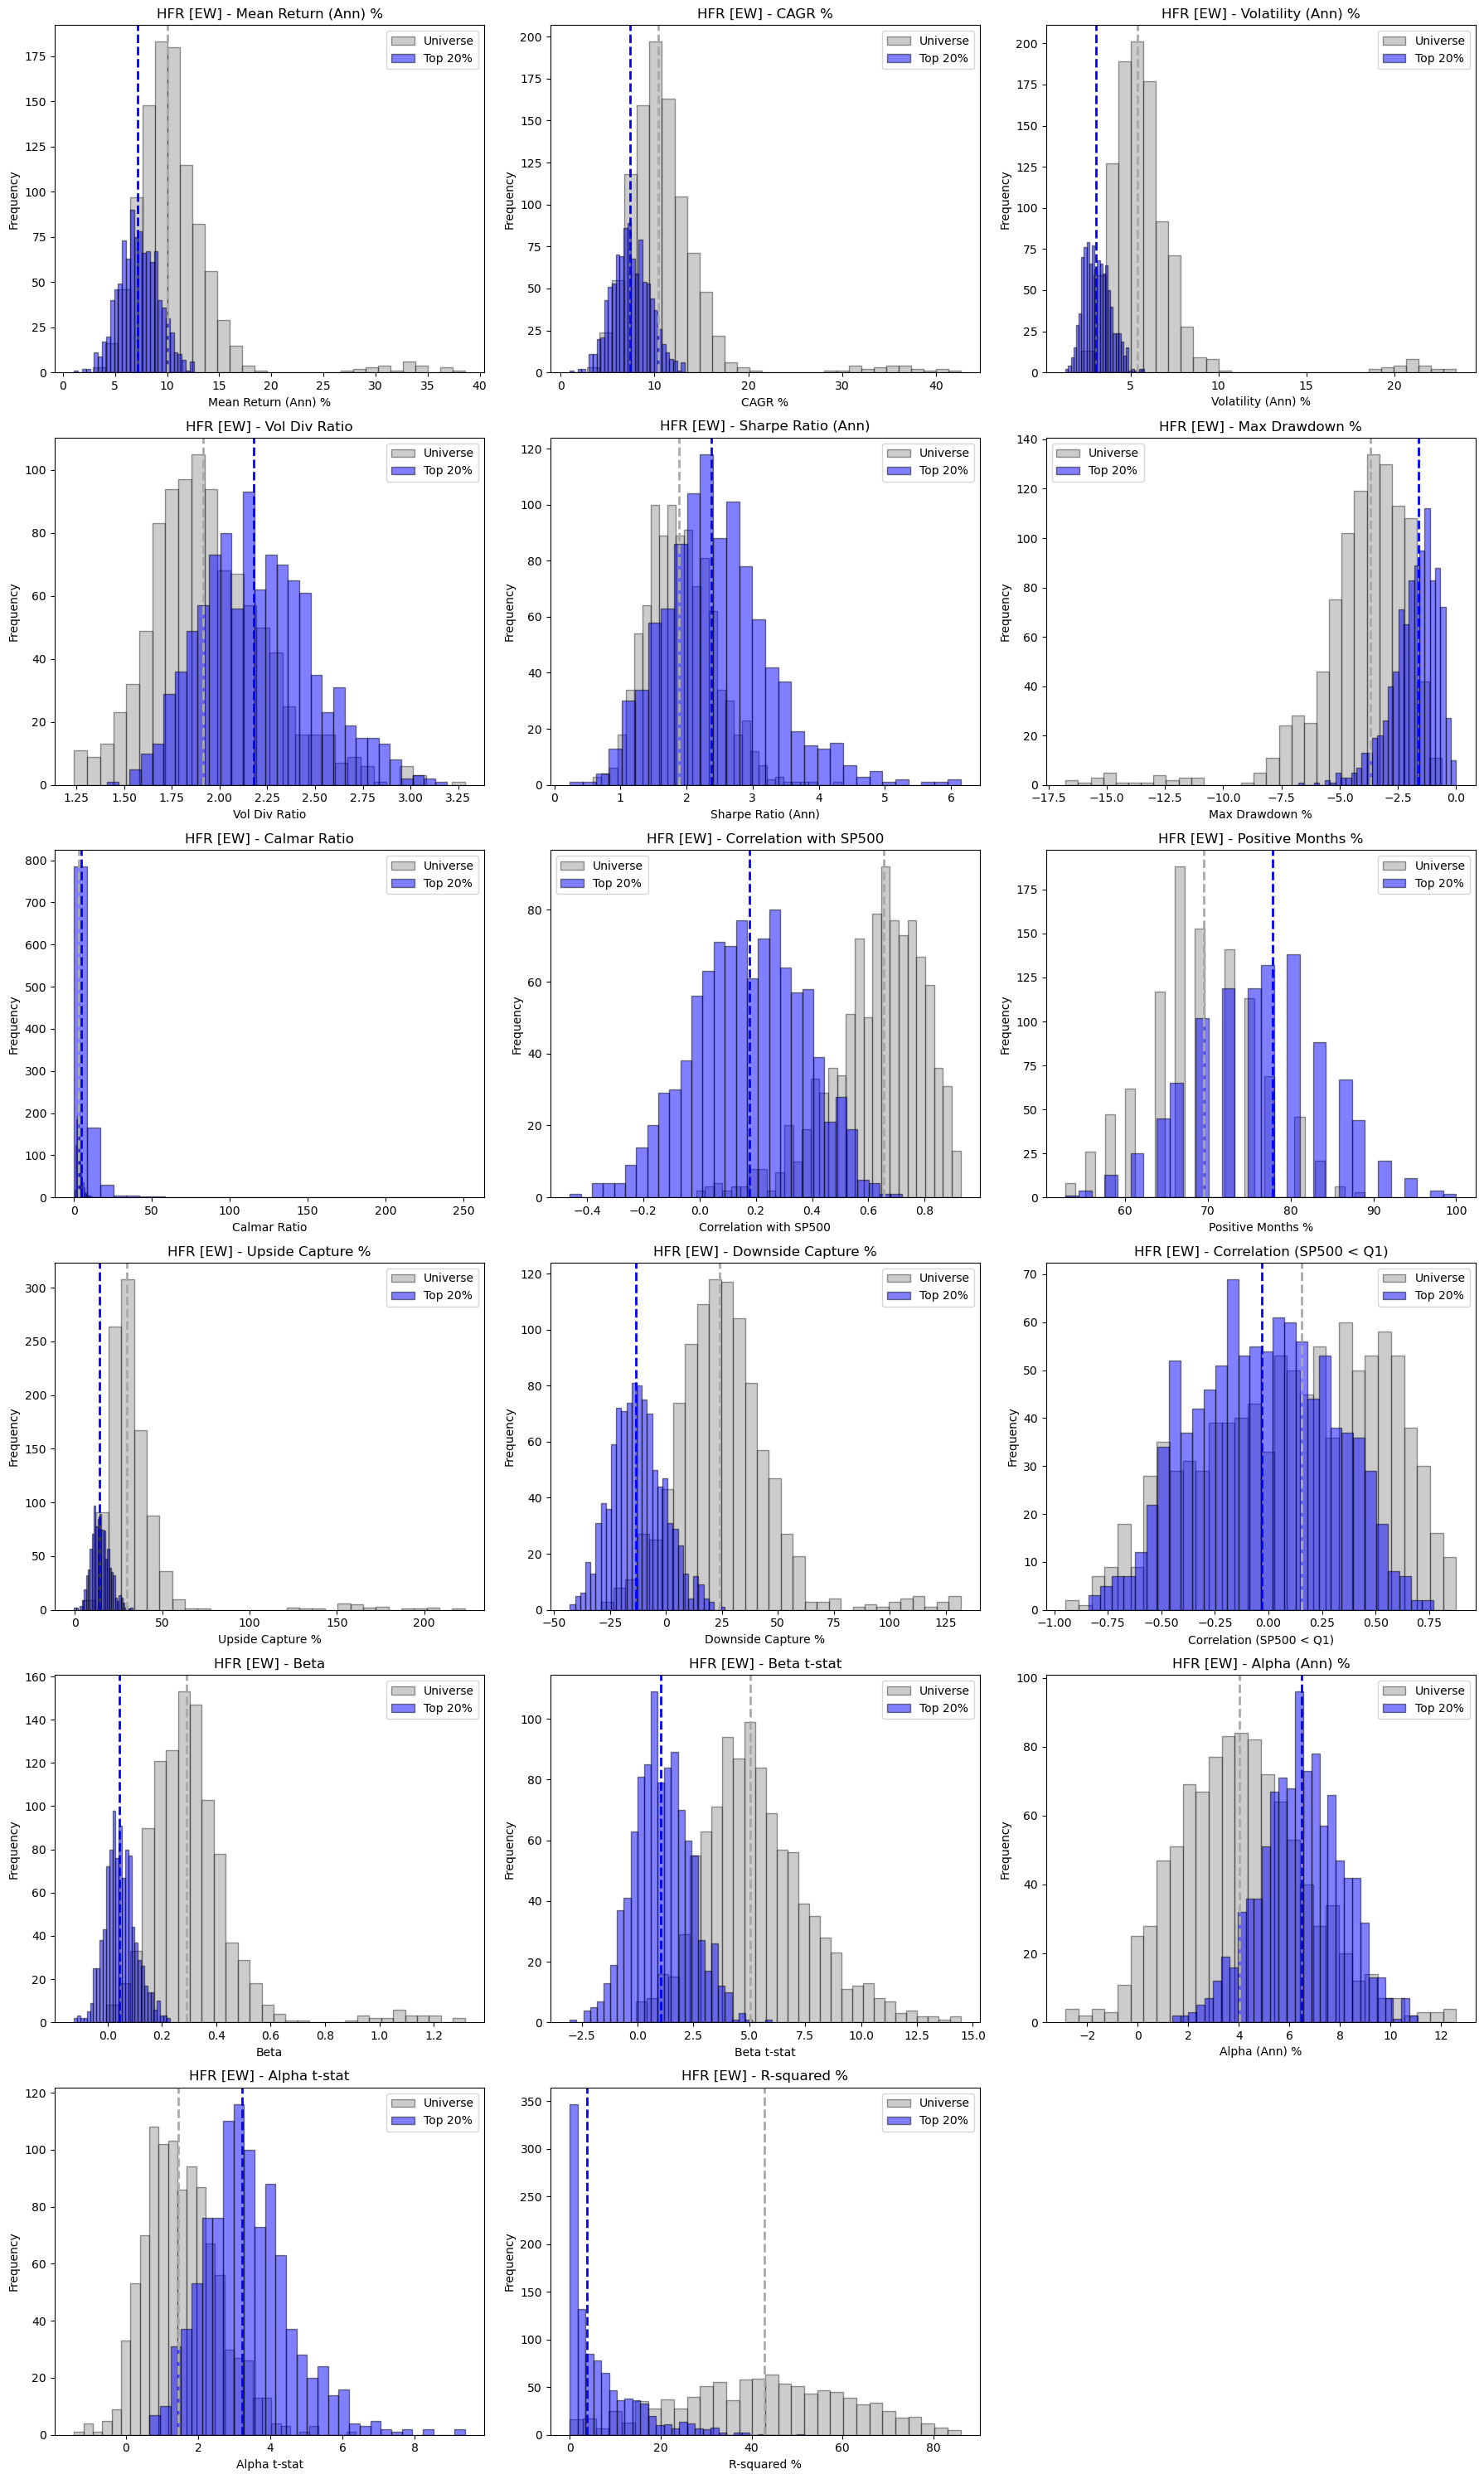

In [ ]:
print("HFR EW: Top 20% vs Universe Boxplots")
plot_universe_comparison_box(res_hfr_10_ew, res_hfr_10_ew_universe, "HFR", "EW")

print("HFR EW: Top 20% vs Universe Overlaid Histograms")
plot_universe_comparison_hist(res_hfr_10_ew, res_hfr_10_ew_universe, "HFR", "EW")


## 8. Summary Table: Top 20% vs Universe

In [ ]:
def create_universe_comparison_table(res_jpm_sel, res_hfr_sel, res_jpm_uni, res_hfr_uni, weight_scheme):
    datasets = {
        ('JPM', 'Top 20%'): res_jpm_sel,
        ('JPM', 'Universe'): res_jpm_uni,
        ('HFR', 'Top 20%'): res_hfr_sel,
        ('HFR', 'Universe'): res_hfr_uni
    }
    
    summary_data = {}
    
    for (data_name, approach), df in datasets.items():
        if df.empty:
            continue
            
        for metric in metrics_to_plot:
            median = df[metric].median()
            summary_data[(data_name, weight_scheme, approach, metric)] = median
            
    summary_series = pd.Series(summary_data)
    summary_series.index.names = ['Dataset', 'Weighting', 'Approach', 'Metric']
    summary_df = summary_series.unstack(level=['Dataset', 'Weighting', 'Approach'])
    
    # Safely reindex keeping existing columns 
    available_datasets = [d for d in ['JPM', 'HFR'] if d in summary_df.columns.get_level_values('Dataset')]
    available_approaches = [a for a in ['Top 20%', 'Universe'] if a in summary_df.columns.get_level_values('Approach')]
    
    summary_df = summary_df.reindex(columns=available_datasets, level='Dataset')
    summary_df = summary_df.reindex(columns=available_approaches, level='Approach')
    summary_df = summary_df.reindex(metrics_to_plot)
    
    return summary_df

comp_table_ew = create_universe_comparison_table(res_jpm_10_ew, res_hfr_10_ew, res_jpm_10_ew_universe, res_hfr_10_ew_universe, 'EW')
comp_table_iv = create_universe_comparison_table(res_jpm_10_iv, res_hfr_10_iv, res_jpm_10_iv_universe, res_hfr_10_iv_universe, 'IV')

# Combine EW and IV for a massive final comparison table
final_comparison = pd.concat([comp_table_ew, comp_table_iv], axis=1)
display(final_comparison.round(2))


Dataset                      JPM              HFR              JPM           \
Weighting                     EW               EW               IV            
Approach                 Top 20% Universe Top 20% Universe Top 20% Universe   
Metric                                                                        
Mean Return (Ann) %         7.97    10.49    7.20    10.06    7.48     9.07   
CAGR %                      8.24    10.88    7.39    10.39    7.73     9.41   
Volatility (Ann) %          2.50     4.48    3.05     5.40    1.70     2.75   
Vol Div Ratio               2.28     1.95    2.18     1.91    3.39     3.17   
Sharpe Ratio (Ann)          3.09     2.36    2.38     1.88    4.36     3.30   
Max Drawdown %             -1.11    -2.75   -1.63    -3.68   -0.51    -1.23   
Calmar Ratio                7.27     3.91    4.70     2.88   14.73     7.48   
Correlation with SP500      0.22     0.66    0.18     0.65    0.24     0.64   
Positive Months %          83.33    75.00   77.78    69.44   88.89    83.33   
Upside Capture %           14.90    28.47   14.22    29.65   13.66    21.15   
Downside Capture %        -15.89    13.73  -13.25    24.09  -19.57    -3.14   
Correlation (SP500 < Q1)    0.09     0.31   -0.03     0.15    0.09     0.32   
Beta                        0.05     0.25    0.04     0.29    0.03     0.14   
Beta t-stat                 1.32     5.17    1.04     5.04    1.44     4.81   
Alpha (Ann) %               7.33     5.26    6.47     4.03    7.00     6.17   
Alpha t-stat                4.26     2.47    3.22     1.45    6.19     4.30   
R-squared %                 5.11    44.03    3.80    42.77    5.87    40.45   

Dataset                      HFR           
Weighting                     IV           
Approach                 Top 20% Universe  
Metric                                     
Mean Return (Ann) %         7.99     8.46  
CAGR %                      8.28     8.75  
Volatility (Ann) %          1.37     2.75  
Vol Div Ratio               4.60     3.68  
Sharpe Ratio (Ann)          6.09     3.04  
Max Drawdown %             -0.17    -1.37  
Calmar Ratio               19.67     6.31  
Correlation with SP500      0.24     0.68  
Positive Months %          97.22    80.56  
Upside Capture %           14.58    20.52  
Downside Capture %        -22.41     2.28  
Correlation (SP500 < Q1)    0.04     0.22  
Beta                        0.02     0.16  
Beta t-stat                 1.42     5.47  
Alpha (Ann) %               7.64     5.21  
Alpha t-stat                8.89     3.83  
R-squared %                 5.71    46.80

Top 25% Sharpe Volatility Distribution - EW


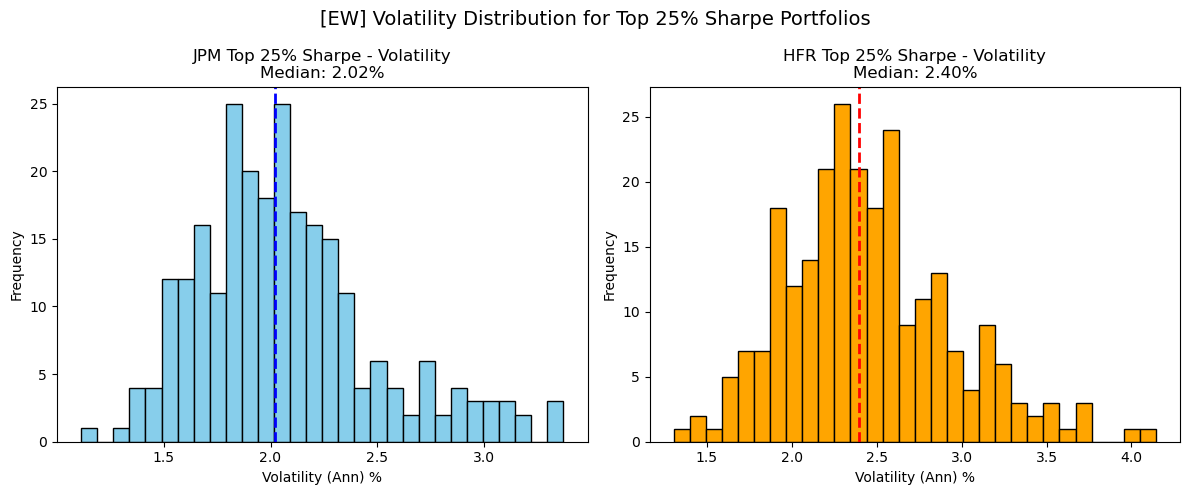

Top 25% Sharpe Volatility Distribution - IV


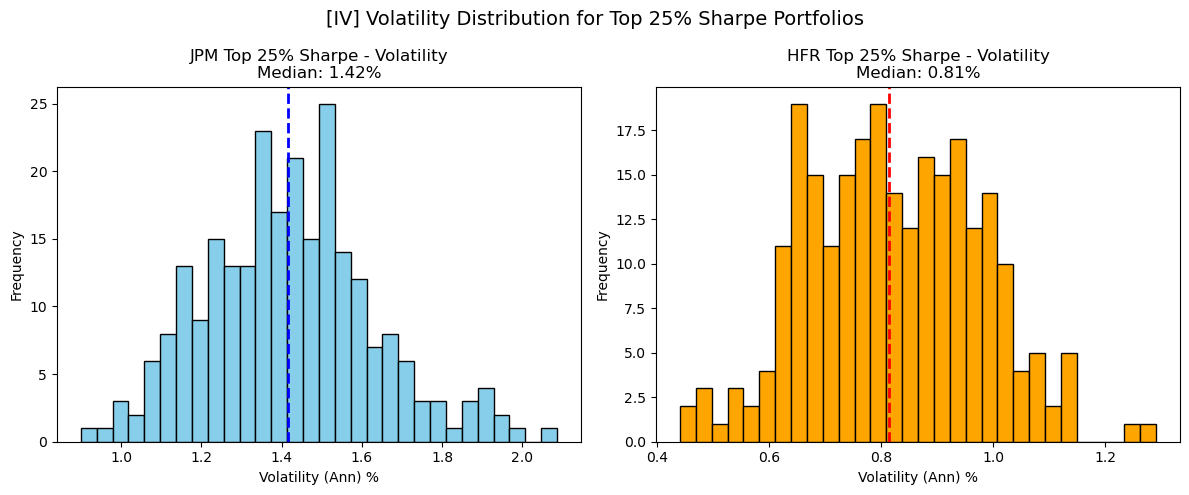

In [ ]:
def plot_top_25_sharpe_vol_distribution(res_jpm, res_hfr, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # JPM
    if not res_jpm.empty:
        q75_jpm = res_jpm['Sharpe Ratio (Ann)'].quantile(0.75)
        top_25_jpm = res_jpm[res_jpm['Sharpe Ratio (Ann)'] >= q75_jpm]
        axes[0].hist(top_25_jpm['Volatility (Ann) %'].dropna(), bins=30, color='skyblue', edgecolor='black')
        axes[0].axvline(top_25_jpm['Volatility (Ann) %'].median(), color='blue', linestyle='dashed', linewidth=2)
        axes[0].set_title(f'JPM Top 25% Sharpe - Volatility\nMedian: {top_25_jpm["Volatility (Ann) %"].median():.2f}%')
        axes[0].set_xlabel('Volatility (Ann) %')
        axes[0].set_ylabel('Frequency')
        
    # HFR
    if not res_hfr.empty:
        q75_hfr = res_hfr['Sharpe Ratio (Ann)'].quantile(0.75)
        top_25_hfr = res_hfr[res_hfr['Sharpe Ratio (Ann)'] >= q75_hfr]
        axes[1].hist(top_25_hfr['Volatility (Ann) %'].dropna(), bins=30, color='orange', edgecolor='black')
        axes[1].axvline(top_25_hfr['Volatility (Ann) %'].median(), color='red', linestyle='dashed', linewidth=2)
        axes[1].set_title(f'HFR Top 25% Sharpe - Volatility\nMedian: {top_25_hfr["Volatility (Ann) %"].median():.2f}%')
        axes[1].set_xlabel('Volatility (Ann) %')
        axes[1].set_ylabel('Frequency')
        
    fig.suptitle(f'{title_prefix} Volatility Distribution for Top 25% Sharpe Portfolios', fontsize=14)
    plt.tight_layout()
    plt.show()

print("Top 25% Sharpe Volatility Distribution - EW")
if 'res_jpm_10_ew' in locals() and 'res_hfr_10_ew' in locals():
    plot_top_25_sharpe_vol_distribution(res_jpm_10_ew, res_hfr_10_ew, "[EW]")

print("Top 25% Sharpe Volatility Distribution - IV")
if 'res_jpm_10_iv' in locals() and 'res_hfr_10_iv' in locals():
    plot_top_25_sharpe_vol_distribution(res_jpm_10_iv, res_hfr_10_iv, "[IV]")
